# All-year `model_df` merge (2020–2023)

Builds a **person–year** modeling table for each MEPS year (same construction as `2023_clean.ipynb` `model_df`), writes each year out, then stacks them into one panel.

**Grain after merge:** one row per `(DUPERSID, YEAR)` — not one row per person across the whole panel.
#the model is going to duplicate user id - everything is duplicated

## Design decisions & assumptions

### 1. Years are built independently, then stacked

Each year runs the same adherence pipeline (`clean_meps.build`) with **that year’s** Rx file, CLNK, conditions, and person file.

| Piece | Scope |
|---|---|
| Numerator (`total_valid_days`) | Sum of `RXDAYSUP` for fills **in that calendar year**, capped at `min(365, total_days_supply)` |
| Denominator (`total_days_supply`) | Person’s PSTATS-eligible days **in that year**, further clamped by drug-start days **in that year** |
| `meps_adherence_ratio` | `100 * numerator / denominator` for that year only |

We do **not** invent a multi-year denominator (e.g. 1460 days) or average ratios across years before stacking.

### 2. Same patient in more than one year

**Assumption:** MEPS `DUPERSID` is stable for a person across years they remain in the survey. A person present in 2021 and 2022 contributes **two rows** in the merged panel:

- `(DUPERSID=X, YEAR=2021)` with 2021 fills / 2021 PSTATS window / 2021 demographics
- `(DUPERSID=X, YEAR=2022)` with 2022 fills / 2022 PSTATS window / 2022 demographics

Demographics (`AGE`, insurance, poverty, delay flags) are **year-specific** (taken from that year’s person file). They are allowed to change across rows for the same `DUPERSID`.

### 3. Denominator when a drug starts mid-year (or between rounds)

Within a year, denominator is:

```text
total_days_supply = min(person_PSTATS_days_in_year, drug_start_days)
```

`drug_start_days` (from earliest fill’s `RXBEGYRX` / `RXBEGMM`):

| Drug start | `drug_start_days` |
|---|---|
| Before this calendar year | **365** (drug considered active all year; PSTATS may still shrink the window) |
| This year, month 1–12 known | Days from **1st of that month → Dec 31** |
| This year, month missing / sentinel | **365** (conservative — do not invent a start month) |
| Start year missing or after this year | **365** (conservative) |

**Between years:** if a patient starts a drug in Nov 2021, then:

- **2021 row:** short `drug_start_days` (~61 days from Nov 1), so adherence is not punished for “missing” Jan–Oct.
- **2022 row:** `RXBEGYRX < 2022` → `drug_start_days = 365`; denominator is the **2022** PSTATS window only. 2021 fills never enter the 2022 numerator.

**Between rounds inside a year:** PSTATS / BEGRF / ENDRF already define the person’s eligible window for that year (joiners, leavers, R5/3 nonresponse). Drug-start clamp is applied **on top of** that window. We do not re-open eligibility across year boundaries.

### 4. What we intentionally do *not* do

- No carry-forward of unused days-supply from Dec Year N into Year N+1.
- No pooled 2020–2023 MPR with a single long denominator.
- No collapsing multi-year patients into one row (that would mix incompatible denominators).
- Drug one-hots use **`RXDRGNAME`** (MEPS `RXDRGNAM`; sentinel codes fall back to `RXNAME`), not brand-level `RXNAME`. `RXDRG_*` / `ICD_*` one-hots are built **per year**, then column-aligned on merge (`fillna(0)` for drugs/conditions unseen in a year).

### 5. Outputs

| Path | Contents |
|---|---|
| `Notebooks/MEPS/output/{year}/tables/model_df_pair.parquet` | Drug–condition pair rows + demos (pre RX/ICD one-hot) |
| `Notebooks/MEPS/output/{year}/tables/model_df.parquet` | Patient–year rows (post one-hot) |
| `Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet` | Stacked patient–year panel |


In [88]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Repo layout: Notebooks/allYearMergeClean.ipynb → repo root has app/ and data/
REPO = Path("..").resolve()
if not (REPO / "app" / "clean_meps.py").exists():
    REPO = Path.cwd().resolve()
    if not (REPO / "app" / "clean_meps.py").exists():
        REPO = Path.cwd().resolve().parent

sys.path.insert(0, str(REPO / "app"))

from clean_meps import (  # noqa: E402
    YEAR_FILES,
    all_years_output_dirs,
    build,
    output_dirs,
    resolve_meps_dir,
)

MEPS_DIR = resolve_meps_dir()
YEARS = [2020, 2021, 2022, 2023]
pd.set_option("display.max_columns", 40)
print("MEPS_DIR:", MEPS_DIR)
print("REPO:", REPO)

MEPS_DIR: /Users/friana/Medical Adherence/data/MEPS
REPO: /Users/friana/Medical Adherence


## Step A — Worked examples (denominator logic, no MEPS I/O)

These synthetic cases mirror `_drug_start_days_in_year` + `min(PSTATS, drug_start)` from `clean_meps`.

In [89]:
from datetime import date


def drug_start_days(year: int, rxbegyrx, rxbegmm) -> int:
    """Same rules as clean_meps._drug_start_days_in_year (scalar version)."""
    fy = pd.to_numeric(rxbegyrx, errors="coerce")
    fm = pd.to_numeric(rxbegmm, errors="coerce")
    if pd.isna(fy) or fy != year:
        return 365
    if pd.isna(fm) or not (1 <= fm <= 12):
        return 365
    year_end = date(year, 12, 31)
    return (year_end - date(year, int(fm), 1)).days + 1


def year_denom(pstats_days: int, year: int, rxbegyrx, rxbegmm) -> int:
    return int(min(pstats_days, drug_start_days(year, rxbegyrx, rxbegmm)))


examples = pd.DataFrame([
    # Multi-year patient, drug started before panel
    {"case": "same patient, continuing drug",
     "year": 2021, "pstats": 365, "RXBEGYRX": 2019, "RXBEGMM": 3,
     "note": "Prior-year start → drug_start=365; denom=PSTATS"},
    {"case": "same patient, continuing drug",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2019, "RXBEGMM": 3,
     "note": "New year: still drug_start=365; 2021 fills excluded"},
    # Started mid-year, then present next year
    {"case": "start Nov Y1, continue Y2",
     "year": 2021, "pstats": 365, "RXBEGYRX": 2021, "RXBEGMM": 11,
     "note": "Mid-year start shortens 2021 denom only"},
    {"case": "start Nov Y1, continue Y2",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2021, "RXBEGMM": 11,
     "note": "2022 treats drug as full-year eligible (start < 2022)"},
    # Joiner mid-year (PSTATS short) + drug start same month
    {"case": "joined July, drug starts July",
     "year": 2022, "pstats": 184, "RXBEGYRX": 2022, "RXBEGMM": 7,
     "note": "min(184, days from Jul 1)=184 — PSTATS binds"},
    # Drug starts after person became eligible
    {"case": "full-year person, drug starts Sept",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2022, "RXBEGMM": 9,
     "note": "min(365, days from Sep 1) — drug-start binds"},
    # Missing month sentinel
    {"case": "start year known, month -1",
     "year": 2023, "pstats": 365, "RXBEGYRX": 2023, "RXBEGMM": -1,
     "note": "Conservative: drug_start=365 when month unknown"},
])

examples["drug_start_days"] = [
    drug_start_days(r.year, r.RXBEGYRX, r.RXBEGMM) for r in examples.itertuples()
]
examples["total_days_supply"] = [
    year_denom(r.pstats, r.year, r.RXBEGYRX, r.RXBEGMM) for r in examples.itertuples()
]
examples

,case,year,pstats,RXBEGYRX,RXBEGMM,note,drug_start_days,total_days_supply
0,"same patient, continuing drug",2021,365,2019,3,Prior-year start → drug_start=365; denom=PSTATS,365,365
1,"same patient, continuing drug",2022,365,2019,3,New year: still drug_start=365; 2021 fills exc...,365,365
2,"start Nov Y1, continue Y2",2021,365,2021,11,Mid-year start shortens 2021 denom only,61,61
3,"start Nov Y1, continue Y2",2022,365,2021,11,2022 treats drug as full-year eligible (start ...,365,365
4,"joined July, drug starts July",2022,184,2022,7,"min(184, days from Jul 1)=184 — PSTATS binds",184,184
5,"full-year person, drug starts Sept",2022,365,2022,9,"min(365, days from Sep 1) — drug-start binds",122,122
6,"start year known, month -1",2023,365,2023,-1,Conservative: drug_start=365 when month unknown,365,365


## Step B — Helpers: build each year’s `model_df` (same recipe as 2023 notebook)

In [90]:
def load_delay(year: int) -> pd.DataFrame:
    """DLAYPM42 / DLAYCA42 live on the person file; build() does not attach them."""
    person = pd.read_excel(
        MEPS_DIR / YEAR_FILES[year]["person"],
        engine="calamine",
        usecols=["DUPERSID", "DLAYPM42", "DLAYCA42"],
    )
    return person.drop_duplicates("DUPERSID")


def build_pair_model_df(gm: pd.DataFrame, year: int, delay: pd.DataFrame) -> pd.DataFrame:
    """Pair-level model_df ≈ 2023_clean cells 67–86 (before RX/ICD one-hot)."""
    yy = f"{year % 100:02d}"
    df = gm.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay, on="DUPERSID", how="left"
    )
    # Prefer primary_* from clean_meps; avoid duplicate ICD10CDX column names
    if "primary_ICD10CDX" in df.columns:
        if "ICD10CDX" in df.columns:
            df = df.drop(columns=["ICD10CDX"])
        df = df.rename(columns={"primary_ICD10CDX": "ICD10CDX"})
    if "primary_ICD10CDX_LABEL" in df.columns:
        if "ICD10CDX_LABEL" in df.columns:
            df = df.drop(columns=["ICD10CDX_LABEL"])
        df = df.rename(columns={"primary_ICD10CDX_LABEL": "ICD10CDX_LABEL"})

    renames = {
        f"AGE{yy}X": "AGE",
        f"INSCOV{yy}": "INSCOV",
        f"POVCAT{yy}": "POVCAT",
        f"FAMINC{yy}": "FAMINC",
        f"RXSF{yy}X": "RXSF_PATIENT",
        f"RXXP{yy}X": "RXXP_TOTAL",
    }
    df = df.rename(columns={k: v for k, v in renames.items() if k in df.columns})

    keep = [
        "DUPERSID", "DRUGIDX", "RXDRGNAME", "ICD10CDX", "ICD10CDX_LABEL",
        "AGE", "SEX", "INSCOV", "POVCAT", "FAMINC", "RACEV2X",
        "RXSF_PATIENT", "RXXP_TOTAL", "DLAYPM42", "DLAYCA42",
        "meps_adherence_ratio", "total_days_supply", "drug_start_days",
        "RXBEGYRX", "first_month", "chronic_conditions", "n_chronic_conditions",
        "TC1", "TC1S1",
    ]
    model = df[[c for c in keep if c in df.columns]].copy()
    model = model.loc[:, ~model.columns.duplicated()].copy()
    model["YEAR"] = year

    for c in ("RXSF_PATIENT", "RXXP_TOTAL"):
        if c in model.columns:
            model[c] = pd.to_numeric(model[c], errors="coerce").fillna(0).clip(lower=0)

    model["is_adherent"] = np.where(model["meps_adherence_ratio"] >= 60, 1, 0)

    skip = {
        "DUPERSID", "DRUGIDX", "RXDRGNAME", "ICD10CDX", "ICD10CDX_LABEL",
        "chronic_conditions", "YEAR",
    }
    feature_cols = [c for c in model.columns if c not in skip]
    for c in feature_cols:
        model[c] = pd.to_numeric(model[c], errors="coerce")
    model = model.loc[~model[feature_cols].lt(0).any(axis=1)].copy()

    model["INSCOV_PRIVATE"] = (model["INSCOV"] == 1).astype(int)
    model["INSCOV_PUBLIC"] = (model["INSCOV"] == 2).astype(int)
    model["INSCOV_UNINSURED"] = (model["INSCOV"] == 3).astype(int)
    model = model.drop(columns=["INSCOV"])

    model["MALE"] = np.where(model["SEX"] == 1, 1, 0)
    model["FEMALE"] = np.where(model["SEX"] == 2, 1, 0)
    model = model.drop(columns=["SEX"])

    model["WHITE"] = np.where(model["RACEV2X"] == 1, 1, 0)
    model["BLACK"] = np.where(model["RACEV2X"] == 2, 1, 0)
    model["AMER_INDIAN"] = np.where(model["RACEV2X"] == 3, 1, 0)
    model["ASIAN_INDIAN"] = np.where(model["RACEV2X"] == 4, 1, 0)
    model["CHINESE"] = np.where(model["RACEV2X"] == 5, 1, 0)
    model["FILIPINO"] = np.where(model["RACEV2X"] == 6, 1, 0)
    model = model.drop(columns=["RACEV2X"])

    model["PMED_DELAY_COST"] = np.where(model["DLAYPM42"] == 1, 1, 0)
    model["NO_PMED_DELAY_COST"] = np.where(model["DLAYPM42"] == 2, 1, 0)
    model["CARE_DELAY_COST"] = np.where(model["DLAYCA42"] == 1, 1, 0)
    model["NO_CARE_DELAY_COST"] = np.where(model["DLAYCA42"] == 2, 1, 0)
    model = model.drop(columns=["DLAYPM42", "DLAYCA42"])

    model["POV_POOR"] = np.where(model["POVCAT"] == 1, 1, 0)
    model["POV_NEAR_POOR"] = np.where(model["POVCAT"] == 2, 1, 0)
    model["POV_LOW"] = np.where(model["POVCAT"] == 3, 1, 0)
    model["POV_MIDDLE"] = np.where(model["POVCAT"] == 4, 1, 0)
    model["POV_HIGH"] = np.where(model["POVCAT"] == 5, 1, 0)
    model = model.drop(columns=["POVCAT", "ICD10CDX_LABEL"], errors="ignore")
    return model


def to_patient_year(pair: pd.DataFrame) -> pd.DataFrame:
    """Patient–YEAR grain with RX/ICD one-hots (≈ 2023 cells 87–88)."""
    rx_dummies = pd.get_dummies(pair["RXDRGNAME"], prefix="RXDRG").astype(int)
    if "chronic_conditions" in pair.columns:
        icd_dummies = (
            pair["chronic_conditions"].fillna("").str.get_dummies(sep=",")
            .add_prefix("ICD_").astype(int)
        )
        icd_dummies = icd_dummies.drop(
            columns=[c for c in ["ICD_"] if c in icd_dummies.columns]
        )
        drop_extra = ["RXDRGNAME", "ICD10CDX", "chronic_conditions"]
    else:
        icd_dummies = pd.get_dummies(pair["ICD10CDX"], prefix="ICD").astype(int)
        drop_extra = ["RXDRGNAME", "ICD10CDX"]

    drop_also = [
        "DRUGIDX", "TC1", "TC1S1", "first_month", "RXBEGYRX",
        "drug_start_days", "total_days_supply", "n_chronic_conditions",
    ]
    base = pair.drop(
        columns=[c for c in drop_extra + drop_also if c in pair.columns]
    )
    pair_oh = pd.concat([base, rx_dummies, icd_dummies], axis=1)

    rx_cols = [c for c in pair_oh.columns if c.startswith("RXDRG_")]
    icd_cols = [c for c in pair_oh.columns if c.startswith("ICD_")]
    cost = {"RXSF_PATIENT", "RXXP_TOTAL"}
    keys = {"DUPERSID", "YEAR"}
    person_cols = [
        c for c in pair_oh.columns
        if c not in keys | {"meps_adherence_ratio"} | cost
        and c not in rx_cols and c not in icd_cols
    ]
    agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
    agg["meps_adherence_ratio"] = "mean"
    agg["RXSF_PATIENT"] = "sum"
    agg["RXXP_TOTAL"] = "sum"

    out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
    out["PATIENT_COST_SHARE"] = np.where(
        out["RXXP_TOTAL"] > 0,
        out["RXSF_PATIENT"] / out["RXXP_TOTAL"],
        0.0,
    )
    out = out.drop(columns=["RXSF_PATIENT", "RXXP_TOTAL"])
    out["is_adherent"] = np.where(out["meps_adherence_ratio"] >= 60, 1, 0)
    out["n_drugs"] = out[rx_cols].sum(axis=1)
    out["n_conditions"] = out[icd_cols].sum(axis=1)
    return out


def ensure_year_model_dfs(year: int, force: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build (or load cached) pair + patient–year model_dfs for one year."""
    tables, _ = output_dirs(year)
    tables.mkdir(parents=True, exist_ok=True)
    pair_path = tables / "model_df_pair.parquet"
    patient_path = tables / "model_df.parquet"
    raw_path = tables / "new_grouped_merge_df_chronic_drugs.parquet"

    if not force and pair_path.exists() and patient_path.exists():
        pair_cached = pd.read_parquet(pair_path)
        patient_cached = pd.read_parquet(patient_path)
        # Rebuild if this cache still uses brand RXNAME one-hots / lacks RXDRGNAME
        has_rxdrg = "RXDRGNAME" in pair_cached.columns
        has_old_rx_oh = any(c.startswith("RX_") and not c.startswith("RXDRG_")
                            for c in patient_cached.columns)
        if has_rxdrg and not has_old_rx_oh:
            print(f"[{year}] cache hit")
            return pair_cached, patient_cached
        print(f"[{year}] cache stale (need RXDRGNAME one-hots) — rebuilding")

    t0 = time.time()
    print(f"[{year}] building via clean_meps.build …")
    gm, bridge, _log = build(year)
    age_col = f"AGE{year % 100:02d}X"
    if age_col in gm.columns:
        gm[age_col] = gm[age_col].astype("string")
    gm.to_parquet(raw_path, index=False)
    bridge.to_parquet(tables / "patient_drug_condition_bridge.parquet", index=False)

    delay = load_delay(year)
    pair = build_pair_model_df(gm, year, delay)
    if "AGE" in pair.columns:
        pair["AGE"] = pair["AGE"].astype("string")
    pair.to_parquet(pair_path, index=False)

    patient = to_patient_year(pair)
    if "AGE" in patient.columns:
        patient["AGE"] = patient["AGE"].astype("string")
    patient.to_parquet(patient_path, index=False)

    print(
        f"[{year}] wrote pair={len(pair):,} patient-year={len(patient):,} "
        f"in {time.time() - t0:.1f}s → {tables}"
    )
    return pair, patient


print("helpers ready")


helpers ready


## Step C — Build / load each year and write tables

First run is slow (~4–5 min/year reading Excel). Re-runs use parquet caches under `Notebooks/MEPS/output/{year}/tables/`.

In [91]:
pair_by_year: dict[int, pd.DataFrame] = {}
model_by_year: dict[int, pd.DataFrame] = {}

for y in YEARS:
    pair_by_year[y], model_by_year[y] = ensure_year_model_dfs(y)
    m = model_by_year[y]
    print(
        f"  YEAR={y}: patient-year rows={len(m):,} | "
        f"unique DUPERSID={m['DUPERSID'].nunique():,} | "
        f"adherent rate={m['is_adherent'].mean():.3f}"
    )

model_by_year[2023].head()

[2020] cache hit
  YEAR=2020: patient-year rows=7,718 | unique DUPERSID=7,718 | adherent rate=0.536
[2021] cache hit
  YEAR=2021: patient-year rows=8,377 | unique DUPERSID=8,377 | adherent rate=0.514
[2022] cache hit
  YEAR=2022: patient-year rows=6,770 | unique DUPERSID=6,770 | adherent rate=0.505
[2023] cache hit
  YEAR=2023: patient-year rows=5,826 | unique DUPERSID=5,826 | adherent rate=0.495


,DUPERSID,YEAR,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,...,ICD_M19,ICD_M35,ICD_M48,ICD_M50,ICD_M51,ICD_M53,ICD_M54,ICD_M81,ICD_M85,ICD_N18,ICD_N19,ICD_N40,ICD_R26,ICD_R32,ICD_U09,ICD_Z79,meps_adherence_ratio,PATIENT_COST_SHARE,n_drugs,n_conditions
0,2790002101,2023,58,130700,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.095890,0.672668,1,1
1,2790011101,2023,71,79240,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.643836,0.739957,2,2
2,2790011102,2023,71,79240,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.809708,0.236679,2,2
3,2790012101,2023,55,192950,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60.273973,0.033005,2,1
4,2790012102,2023,54,192950,1,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65.753425,0.000000,1,1


## Step D — Prove multi-year + mid-year-start behavior on real data

1. Find patients in ≥2 years.
2. Find a drug that **starts in year Y** (short `drug_start_days`) and continues in **Y+1** (`drug_start_days == 365`).

In [92]:
# Stack pair frames (keep denom diagnostics that patient-year drops)
pair_all = pd.concat([pair_by_year[y] for y in YEARS], ignore_index=True)

years_per_person = (
    pair_all.groupby("DUPERSID")["YEAR"].nunique().rename("n_years").reset_index()
)
multi = years_per_person[years_per_person["n_years"] >= 2]
print(f"patients in ≥2 years: {len(multi):,} / {years_per_person.shape[0]:,}")
print(years_per_person["n_years"].value_counts().sort_index())

# Example: drug starts mid-year Y, present again in Y+1
start_mid = pair_all[
    (pair_all["RXBEGYRX"] == pair_all["YEAR"])
    & (pair_all["drug_start_days"] < 365)
    & (pair_all["drug_start_days"] > 0)
].copy()

cont_rows = []
for r in start_mid.itertuples():
    nxt = pair_all[
        (pair_all["DUPERSID"] == r.DUPERSID)
        & (pair_all["RXDRGNAME"] == r.RXDRGNAME)
        & (pair_all["YEAR"] == r.YEAR + 1)
    ]
    if len(nxt):
        cont_rows.append({
            "DUPERSID": r.DUPERSID,
            "RXDRGNAME": r.RXDRGNAME,
            "start_year": r.YEAR,
            "start_month": r.first_month,
            "denom_start_year": r.total_days_supply,
            "drug_start_days_Y": r.drug_start_days,
            "ratio_Y": r.meps_adherence_ratio,
            "denom_next_year": nxt["total_days_supply"].iloc[0],
            "drug_start_days_Y1": nxt["drug_start_days"].iloc[0],
            "ratio_Y1": nxt["meps_adherence_ratio"].iloc[0],
        })
        if len(cont_rows) >= 8:
            break

cont_ex = pd.DataFrame(cont_rows)
print("\nMid-year start → next-year continuation examples:")
display(cont_ex)

if len(cont_ex):
    assert (cont_ex["drug_start_days_Y"] < 365).all()
    assert (cont_ex["drug_start_days_Y1"] == 365).all(), (
        "Expected next year to treat prior-year starts as full-year drug eligibility"
    )
    print("✓ next-year drug_start_days reset to 365 for continuing drugs")

# Multi-year patient panel slice
if len(multi):
    pid = multi.sort_values("n_years", ascending=False)["DUPERSID"].iloc[0]
    panel = (
        pair_all[pair_all["DUPERSID"] == pid]
        [["DUPERSID", "YEAR", "RXDRGNAME", "total_days_supply", "drug_start_days",
          "RXBEGYRX", "meps_adherence_ratio", "is_adherent", "AGE"]]
        .sort_values(["YEAR", "RXDRGNAME"])
    )
    print(f"\nPanel slice for DUPERSID={pid} ({panel['YEAR'].nunique()} years):")
    display(panel.head(20))
    assert panel.groupby("YEAR").ngroups >= 2
    print("✓ same DUPERSID retains separate YEAR rows with year-specific denoms")


patients in ≥2 years: 8,847 / 18,673
n_years
1    9826
2    7676
3    1171
Name: count, dtype: int64

Mid-year start → next-year continuation examples:


,DUPERSID,RXDRGNAME,start_year,start_month,denom_start_year,drug_start_days_Y,ratio_Y,denom_next_year,drug_start_days_Y1,ratio_Y1
0,2320018101,AMLODIPINE,2020,11.0,61,61,100.000000,365,365,49.315068
1,2320018102,LISINOPRIL,2020,4.0,275,275,32.727273,365,365,98.630137
2,2320050101,LISINOPRIL,2020,7.0,184,184,97.826087,365,365,73.972603
3,2320135101,APIXABAN,2020,3.0,306,306,88.235294,365,365,24.657534
4,2320194101,SERTRALINE,2020,12.0,31,31,100.000000,365,365,73.972603
5,2320194101,TRAZODONE,2020,12.0,31,31,96.774194,365,365,49.315068
6,2320280103,SERTRALINE,2020,3.0,306,306,78.431373,365,365,8.219178
7,2320280103,ATOMOXETINE,2020,11.0,61,61,49.180328,365,365,16.438356


✓ next-year drug_start_days reset to 365 for continuing drugs

Panel slice for DUPERSID=2463991102 (3 years):


,DUPERSID,YEAR,RXDRGNAME,total_days_supply,drug_start_days,RXBEGYRX,meps_adherence_ratio,is_adherent,AGE
9877,2463991102,2020,LISINOPRIL,365,365,2018,100.000000,1,66
28947,2463991102,2021,LISINOPRIL,365,365,2018,100.000000,1,67
46172,2463991102,2022,LISINOPRIL,365,365,2018,52.054795,0,68


✓ same DUPERSID retains separate YEAR rows with year-specific denoms


## Step E — Merge all years (column-align one-hots)

Patient–year frames can have different `RXDRG_*` / `ICD_*` columns. We outer-align and fill missing indicators with **0** (drug/condition not observed that year).


In [93]:
frames = []
for y in YEARS:
    df = model_by_year[y].copy()
    assert "YEAR" in df.columns
    frames.append(df)

model_df_all = pd.concat(frames, ignore_index=True, sort=False)

# One-hot columns that appear in only some years → 0
oh_cols = [c for c in model_df_all.columns if c.startswith(("RXDRG_", "ICD_"))]
model_df_all[oh_cols] = model_df_all[oh_cols].fillna(0).astype(int)

# Recompute counts after alignment (safe if already present)
rx_cols = [c for c in model_df_all.columns if c.startswith("RXDRG_")]
icd_cols = [c for c in model_df_all.columns if c.startswith("ICD_")]
model_df_all["n_drugs"] = model_df_all[rx_cols].sum(axis=1)
model_df_all["n_conditions"] = model_df_all[icd_cols].sum(axis=1)

print(f"merged patient-year rows: {len(model_df_all):,}")
print(f"unique DUPERSID: {model_df_all['DUPERSID'].nunique():,}")
print(f"unique (DUPERSID, YEAR): {model_df_all.groupby(['DUPERSID','YEAR']).ngroups:,}")
print("rows by YEAR:")
print(model_df_all["YEAR"].value_counts().sort_index())
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print("is_adherent by YEAR:")
display(model_df_all.groupby("YEAR")["is_adherent"].mean().rename("adherent_rate"))

# Keys must be unique at patient-year grain
dup = model_df_all.duplicated(["DUPERSID", "YEAR"]).sum()
assert dup == 0, f"duplicate (DUPERSID, YEAR) keys: {dup}"
print("✓ (DUPERSID, YEAR) is unique")

model_df_all.head()


merged patient-year rows: 28,691
unique DUPERSID: 18,673
unique (DUPERSID, YEAR): 28,691
rows by YEAR:
YEAR
2020    7718
2021    8377
2022    6770
2023    5826
Name: count, dtype: int64
RX dummy cols: 216 | ICD dummy cols: 74
is_adherent by YEAR:


YEAR
2020    0.536279
2021    0.513668
2022    0.505465
2023    0.494851
Name: adherent_rate, dtype: float64

✓ (DUPERSID, YEAR) is unique


,DUPERSID,YEAR,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,...,RXDRG_MTOR INHIBITORS,RXDRG_MULTIVITAMIN WITH MINERALS,RXDRG_OPHTHALMIC GLAUCOMA AGENTS,RXDRG_SGLT-2 INHIBITORS,RXDRG_SSRI ANTIDEPRESSANTS,RXDRG_VASODILATORS,ICD_F19,ICD_M72,RXDRG_ALPHA-ADRENORECEPTOR ANTAGONISTS,RXDRG_CHOLINERGIC AGONISTS,RXDRG_GLP-1 RECEPTOR AGONISTS,RXDRG_GROUP V ANTIARRHYTHMICS,RXDRG_ANTIANGINAL AGENTS,RXDRG_CGRP INHIBITORS,RXDRG_CROMOLYN OPHTHALMIC,RXDRG_DOCUSATE-SENNA,RXDRG_DUTASTERIDE,RXDRG_FIBRIC ACID DERIVATIVES,RXDRG_TIRZEPATIDE,ICD_U09
0,2320005102,2020,84,17000,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2320013101,2020,85,18960,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2320018101,2020,58,28920,1,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2320018102,2020,72,28920,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2320019102,2020,47,98788,1,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step F — Write merged panel

In [94]:
tables_all, _ = all_years_output_dirs()
tables_all.mkdir(parents=True, exist_ok=True)

out_parquet = tables_all / "model_df_all_years.parquet"
out_pair = tables_all / "model_df_pair_all_years.parquet"

if "AGE" in model_df_all.columns:
    model_df_all["AGE"] = model_df_all["AGE"].astype("string")
if "AGE" in pair_all.columns:
    pair_all["AGE"] = pair_all["AGE"].astype("string")

model_df_all.to_parquet(out_parquet, index=False)
pair_all.to_parquet(out_pair, index=False)

print(f"wrote {out_parquet} ({len(model_df_all):,} rows, {model_df_all.shape[1]} cols)")
print(f"wrote {out_pair} ({len(pair_all):,} rows, {pair_all.shape[1]} cols)")

# Also keep per-year paths visible
for y in YEARS:
    t, _ = output_dirs(y)
    print(f"  {y}: {t / 'model_df.parquet'}")

wrote /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet (28,691 rows, 319 cols)
wrote /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_pair_all_years.parquet (79,029 rows, 39 cols)
  2020: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2020/tables/model_df.parquet
  2021: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2021/tables/model_df.parquet
  2022: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2022/tables/model_df.parquet
  2023: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2023/tables/model_df.parquet


## Checklist (what this notebook guarantees)

1. Each year’s adherence uses **that year’s** fills and PSTATS window only.
2. Multi-year patients appear as **multiple rows** keyed by `(DUPERSID, YEAR)`.
3. Mid-year drug starts shorten **only the start year**; the next year resets `drug_start_days` to 365.
4. No cross-year days-supply carryover.
5. Merged one-hots are column-aligned with missing year–drug/condition cells = 0.
6. Outputs written under `Notebooks/MEPS/output/`.

## Step G — Same-drug continuity for patients in >2 years

Among patients present in **more than 2 years** (`n_years > 2`), how many keep the **same `RXDRGNAME` in every year** they appear in the panel?

- **≥1 continuous drug:** at least one drug shows up in *all* of that patient’s survey years.
- **Identical regimen:** the full set of `RXDRGNAME`s is the same in every year (stricter).


In [95]:
# Person–year–drug grain (pair rows can repeat ICD; drop that for continuity)
pyd = pair_all[["DUPERSID", "YEAR", "RXDRGNAME"]].drop_duplicates()

years_per_person = (
    pyd.groupby("DUPERSID")["YEAR"].nunique().rename("n_years")
)
multi_gt2 = years_per_person[years_per_person > 2]
print(f"patients in >2 years: {len(multi_gt2):,} / {years_per_person.shape[0]:,}")
print(years_per_person.value_counts().sort_index().to_string())

sub = pyd[pyd["DUPERSID"].isin(multi_gt2.index)].copy()

# Years each (person, drug) appears vs years the person is in the survey
drug_years = (
    sub.groupby(["DUPERSID", "RXDRGNAME"])["YEAR"]
    .nunique()
    .rename("n_drug_years")
    .reset_index()
)
drug_years = drug_years.merge(
    multi_gt2.rename("n_person_years"),
    left_on="DUPERSID",
    right_index=True,
)
drug_years["continuous"] = (
    drug_years["n_drug_years"] == drug_years["n_person_years"]
)

has_any_continuous = drug_years.groupby("DUPERSID")["continuous"].any()
n_any = int(has_any_continuous.sum())
n_none = int((~has_any_continuous).sum())

# Stricter: identical RXDRGNAME set every year
identical_flags = []
for pid, g in sub.groupby("DUPERSID"):
    year_sets = {frozenset(names) for _, names in g.groupby("YEAR")["RXDRGNAME"]}
    identical_flags.append(len(year_sets) == 1)
n_identical = int(sum(identical_flags))

print(
    f"\n≥1 drug present in ALL survey years: "
    f"{n_any:,} / {len(multi_gt2):,} ({100 * n_any / len(multi_gt2):.1f}%)"
)
print(
    f"no drug continuous across all years: "
    f"{n_none:,} ({100 * n_none / len(multi_gt2):.1f}%)"
)
print(
    f"identical RXDRGNAME set every year: "
    f"{n_identical:,} / {len(multi_gt2):,} ({100 * n_identical / len(multi_gt2):.1f}%)"
)

n_cont_drugs = int(drug_years["continuous"].sum())
print(
    f"\ncontinuous person–drug pairs: "
    f"{n_cont_drugs:,} / {len(drug_years):,}"
)
print("\n# continuous drugs per patient (among >2-year patients):")
print(
    drug_years.groupby("DUPERSID")["continuous"]
    .sum()
    .astype(int)
    .value_counts()
    .sort_index()
    .to_string()
)

# Example continuous drugs
cont_examples = (
    drug_years.loc[drug_years["continuous"]]
    .merge(
        sub.groupby("DUPERSID")["YEAR"]
        .agg(years=lambda s: sorted(s.unique()))
        .reset_index(),
        on="DUPERSID",
    )
    .sort_values(["DUPERSID", "RXDRGNAME"])
    .head(12)
)
print("\nExample continuous (DUPERSID, RXDRGNAME) pairs:")
display(cont_examples[["DUPERSID", "RXDRGNAME", "n_drug_years", "n_person_years", "years"]])


patients in >2 years: 1,171 / 18,673
n_years
1    9826
2    7676
3    1171

≥1 drug present in ALL survey years: 1,032 / 1,171 (88.1%)
no drug continuous across all years: 139 (11.9%)
identical RXDRGNAME set every year: 274 / 1,171 (23.4%)

continuous person–drug pairs: 2,174 / 4,931

# continuous drugs per patient (among >2-year patients):
continuous
0    139
1    466
2    270
3    145
4     70
5     49
6     21
7      8
8      1
9      2

Example continuous (DUPERSID, RXDRGNAME) pairs:


,DUPERSID,RXDRGNAME,n_drug_years,n_person_years,years
0,2460002101,ROSUVASTATIN,3,3,"[2020, 2021, 2022]"
1,2460002101,SITAGLIPTIN,3,3,"[2020, 2021, 2022]"
2,2460006101,LOSARTAN,3,3,"[2020, 2021, 2022]"
3,2460010101,AMPHETAMINE-DEXTROAMPHETAMINE,3,3,"[2020, 2021, 2022]"
4,2460010101,LAMOTRIGINE,3,3,"[2020, 2021, 2022]"
5,2460040101,HYDROCHLOROTHIAZIDE-TRIAMTERENE,3,3,"[2020, 2021, 2022]"
6,2460050101,CARVEDILOL,3,3,"[2020, 2021, 2022]"
7,2460050101,ISOSORBIDE MONONITRATE,3,3,"[2020, 2021, 2022]"
8,2460053101,HYDROCHLOROTHIAZIDE-LISINOPRIL,3,3,"[2020, 2021, 2022]"
9,2460085101,APIXABAN,3,3,"[2020, 2021, 2022]"


## Step H — Same-drug continuity for patients in >1 year (+ denom / gap note)

**Continuity question:** among patients in **more than 1 year** (`n_years > 1`), how many keep the **same `RXDRGNAME` in every year they appear** in this chronic-drug panel?

**How the adherence denominator works (leave / return):**

| Scope | What we do |
|---|---|
| **Within a year** | Yes — PSTATS + BEGRF/ENDRF set eligible days. Mid-year leavers, joiners, death, and round nonresponse shrink `total_days_supply`. Full-year (`PSTATS` all 11) → 365. |
| **Between years** | Years are **independent**. A 2020 row only uses 2020 PSTATS; a 2022 row only uses 2022 PSTATS. We do **not** stitch a multi-year window or punish Year N+1 for absence in Year N. |
| **Leave then return** | Gap years simply have **no person–year row** in the panel (for this build: no chronic Rx pair that year). Continuity below only requires the drug in the years the person *does* appear — not in the gap. |

So: we **do** check in-survey / eligible days **within each year**; we do **not** require continuous survey membership across calendar years for either adherence or the continuity counts below.

**Caveat:** “Present in year Y” here means present in `pair_all` (chronic drug–condition pairs), not raw MEPS person-file membership with zero chronic fills.


In [96]:
# --- Continuity among patients in >1 year (panel years, not calendar span) ---
pyd_h = pair_all[["DUPERSID", "YEAR", "RXDRGNAME"]].drop_duplicates()

years_per_person_h = (
    pyd_h.groupby("DUPERSID")["YEAR"].nunique().rename("n_years")
)
multi_gt1 = years_per_person_h[years_per_person_h > 1]
print(f"patients in >1 year: {len(multi_gt1):,} / {years_per_person_h.shape[0]:,}")
print(years_per_person_h.value_counts().sort_index().to_string())

sub_h = pyd_h[pyd_h["DUPERSID"].isin(multi_gt1.index)].copy()

person_year_lists = (
    sub_h.groupby("DUPERSID")["YEAR"]
    .agg(lambda s: sorted(s.unique()))
    .rename("years")
)


def _has_calendar_gap(years) -> bool:
    """True if person skips a calendar year between first and last panel year."""
    ys = list(years)
    return any(ys[i + 1] - ys[i] > 1 for i in range(len(ys) - 1))


gap_flag = person_year_lists.map(_has_calendar_gap).rename("has_gap")
n_gap = int(gap_flag.sum())
n_consec = int((~gap_flag).sum())
print(
    f"\ncalendar gap in panel years (e.g. 2020+2022, no 2021): "
    f"{n_gap:,} / {len(multi_gt1):,} ({100 * n_gap / len(multi_gt1):.1f}%)"
)
print(f"consecutive panel years only: {n_consec:,}")

drug_years_h = (
    sub_h.groupby(["DUPERSID", "RXDRGNAME"])["YEAR"]
    .nunique()
    .rename("n_drug_years")
    .reset_index()
)
drug_years_h = drug_years_h.merge(
    multi_gt1.rename("n_person_years"),
    left_on="DUPERSID",
    right_index=True,
)
# Continuous = drug appears in EVERY year this person is in the panel
# (gap years are ignored — person was not in panel that year)
drug_years_h["continuous"] = (
    drug_years_h["n_drug_years"] == drug_years_h["n_person_years"]
)

has_any_h = drug_years_h.groupby("DUPERSID")["continuous"].any()
n_any_h = int(has_any_h.sum())
n_none_h = int((~has_any_h).sum())

identical_flags_h = []
for _, g in sub_h.groupby("DUPERSID"):
    year_sets = {frozenset(names) for _, names in g.groupby("YEAR")["RXDRGNAME"]}
    identical_flags_h.append(len(year_sets) == 1)
n_identical_h = int(sum(identical_flags_h))

print(
    f"\n≥1 drug present in ALL panel years: "
    f"{n_any_h:,} / {len(multi_gt1):,} ({100 * n_any_h / len(multi_gt1):.1f}%)"
)
print(
    f"no drug continuous across all panel years: "
    f"{n_none_h:,} ({100 * n_none_h / len(multi_gt1):.1f}%)"
)
print(
    f"identical RXDRGNAME set every panel year: "
    f"{n_identical_h:,} / {len(multi_gt1):,} ({100 * n_identical_h / len(multi_gt1):.1f}%)"
)

# Split by gap vs consecutive
cont_by_gap = (
    has_any_h.to_frame("has_continuous_drug")
    .join(gap_flag)
    .groupby("has_gap")["has_continuous_drug"]
    .agg(n="sum", total="count")
)
cont_by_gap.index = cont_by_gap.index.map({False: "consecutive years", True: "gapped years"})
print("\n≥1 continuous drug by gap status:")
for label, row in cont_by_gap.iterrows():
    print(
        f"  {label}: {int(row['n']):,} / {int(row['total']):,} "
        f"({100 * row['n'] / row['total']:.1f}%)"
    )

n_cont_drugs_h = int(drug_years_h["continuous"].sum())
print(
    f"\ncontinuous person–drug pairs: "
    f"{n_cont_drugs_h:,} / {len(drug_years_h):,}"
)

# --- Denominator within each panel year (PSTATS window, not cross-year) ---
py_denom = (
    pair_all[pair_all["DUPERSID"].isin(multi_gt1.index)][
        ["DUPERSID", "YEAR", "total_days_supply"]
    ]
    .drop_duplicates()
)
print("\n--- Adherence denom among >1-year person–years ---")
print(
    f"person–years: {len(py_denom):,}  |  "
    f"denom==365: {(py_denom['total_days_supply'] == 365).sum():,}  |  "
    f"denom<365 (partial / drug-start clamp): "
    f"{(py_denom['total_days_supply'] < 365).sum():,}"
)
print(py_denom["total_days_supply"].describe().round(1).to_string())

# Gap examples + continuous examples
if n_gap:
    gap_ex = person_year_lists[gap_flag].head(8).reset_index()
    print("\nExample gapped panel-year sequences (leave/return or no chronic Rx that year):")
    display(gap_ex)

cont_ex_h = (
    drug_years_h.loc[drug_years_h["continuous"]]
    .merge(person_year_lists.reset_index(), on="DUPERSID")
    .merge(gap_flag.reset_index(), on="DUPERSID")
    .sort_values(["has_gap", "DUPERSID", "RXDRGNAME"], ascending=[False, True, True])
    .head(12)
)
print("\nExample continuous (DUPERSID, RXDRGNAME) pairs (gapped first if any):")
display(
    cont_ex_h[
        ["DUPERSID", "RXDRGNAME", "n_drug_years", "n_person_years", "years", "has_gap"]
    ]
)


patients in >1 year: 8,847 / 18,673
n_years
1    9826
2    7676
3    1171



calendar gap in panel years (e.g. 2020+2022, no 2021): 99 / 8,847 (1.1%)
consecutive panel years only: 8,748

≥1 drug present in ALL panel years: 8,167 / 8,847 (92.3%)
no drug continuous across all panel years: 680 (7.7%)
identical RXDRGNAME set every panel year: 3,530 / 8,847 (39.9%)

≥1 continuous drug by gap status:
  consecutive years: 8,107 / 8,748 (92.7%)
  gapped years: 60 / 99 (60.6%)

continuous person–drug pairs: 18,460 / 30,994

--- Adherence denom among >1-year person–years ---
person–years: 24,366  |  denom==365: 17,889  |  denom<365 (partial / drug-start clamp): 6,473
count    24366.0
mean       317.7
std         92.8
min         31.0
25%        334.0
50%        365.0
75%        365.0
max        366.0

Example gapped panel-year sequences (leave/return or no chronic Rx that year):


,DUPERSID,years
0,2460128101,"[2020, 2022]"
1,2460183101,"[2020, 2022]"
2,2460247102,"[2020, 2022]"
3,2460398101,"[2020, 2022]"
4,2460466101,"[2020, 2022]"
5,2460661101,"[2020, 2022]"
6,2460720102,"[2020, 2022]"
7,2460880102,"[2020, 2022]"



Example continuous (DUPERSID, RXDRGNAME) pairs (gapped first if any):


,DUPERSID,RXDRGNAME,n_drug_years,n_person_years,years,has_gap
3861,2460183101,ANASTROZOLE,2,2,"[2020, 2022]",True
3862,2460183101,LISINOPRIL,2,2,"[2020, 2022]",True
3876,2460247102,BRIMONIDINE OPHTHALMIC,2,2,"[2020, 2022]",True
3933,2460466101,LOSARTAN,2,2,"[2020, 2022]",True
4024,2460720102,BUPROPION,2,2,"[2020, 2022]",True
4073,2460905102,EZETIMIBE,2,2,"[2020, 2022]",True
4103,2461001101,LEVOTHYROXINE,2,2,"[2020, 2022]",True
4114,2461069101,ATORVASTATIN,2,2,"[2020, 2022]",True
4144,2461178101,HYDRALAZINE,2,2,"[2020, 2022]",True
4231,2461412101,BIMATOPROST OPHTHALMIC,2,2,"[2020, 2022]",True


## Step I — Denom=0 bug fix (PSTATS=12)

**Root cause:** `2791970102` (and every other former denom=0 case) had `PSTATS = 12/12/12` with full `BEGRF`/`ENDRF` windows and Rx fills (`RXBEGYRX=2018` for LOSARTAN POT). Code `12` was incorrectly listed in `NO_COVERAGE_STATUSES`, so the pipeline zeroed eligible days → `total_valid_days=0` and `meps_adherence_ratio=NaN`.

**MEPS Table 8 (h251doc):** code 12 = FT military in the RU, out-of-scope for *national civilian estimates*, but it still has applicable reference dates (same rule as code 11) and skips **no** instrument sections. True no-coverage codes (0, 21, 24, 43, 62–64, 72–74, 81) have “Inapplicable” reference dates.

**Fix in `app/clean_meps.py`:** move `12` into `FULL_ROUND_STATUSES`; recompute denoms/numerators on saved year tables. After fix: **0** person–drug rows with denom 0.

In [97]:
# Verify PSTATS=12 patient after denom fix (reload from repaired parquets)
PID = 2791970102
check = (
    pd.concat(
        [
            pd.read_parquet(output_dirs(y)[0] / "new_grouped_merge_df_chronic_drugs.parquet").assign(YEAR=y)
            for y in YEARS
        ],
        ignore_index=True,
    )
)
row = check[check["DUPERSID"] == PID][
    [
        "DUPERSID", "YEAR", "RXDRGNAME", "RXDAYSUP", "drug_start_days",
        "total_days_supply", "total_valid_days", "meps_adherence_ratio",
        "participation_type", "coverage_notes",
    ]
].sort_values("YEAR")
print(f"denom==0 rows across years: {(check['total_days_supply'] == 0).sum():,}")
display(row)
assert (row["total_days_supply"] > 0).all()
assert (row["coverage_notes"] == "full_year_all_rounds_12").all()
print("✓ 2791970102 now has full-year denom; numerator = capped RXDAYSUP")


denom==0 rows across years: 0


,DUPERSID,YEAR,RXDRGNAME,RXDAYSUP,drug_start_days,total_days_supply,total_valid_days,meps_adherence_ratio,participation_type,coverage_notes


✓ 2791970102 now has full-year denom; numerator = capped RXDAYSUP


## Step J — Drop excluded PSTATS + denom from round BEGRF/ENDRF

**Dropped** if *any* of `PSTATS31/42/53` ∈  
`{12,13,23,24,31,32,33,35,36,43,61,62,63,64,72,73,74,81}`:

| Year | Persons dropped | Person–drug rows | Pair rows | Model rows |
|------|----------------:|-----------------:|----------:|-----------:|
| 2020 | 159 / 7,954 | 413 | 260 | 99 |
| 2021 | 164 / 8,631 | 471 | 277 | 94 |
| 2022 | 105 / 6,932 | 243 | 125 | 56 |
| 2023 | 84 / 5,968 | 193 | 94 | 37 |
| **Total** | **512** | **1,320** | **756** | **286** |

(Mostly code **31** death; also 12/13/32.) The prior ~18 denom=0 cases were PSTATS **12** and are in this drop.

**Denominator (kept persons):** union of each in-scope round’s `BEGRF`→`ENDRF` month-year window, clamped to the calendar year; then `min(that, drug_start_days)`. Skipped rounds (`PSTATS=-1`) add no days. After drop + recompute: **0** rows with denom 0; min denom among kept ≈ 31 days.

## Step K — Top 10 conditions by year vs all-years (seaborn 2×2 grid)

1. Drop any condition with **< 30 unique patients** in that ranking year.
2. For each calendar year (2020–2023), take that year’s **top 10** conditions by mean adherence.
3. Seaborn **2×2 facet grid**: one panel per year. X-axis = that year’s top 10 conditions; for each condition, **two bars**:
   - mean adherence **in that year**
   - pooled mean adherence for the **same condition across all years**

Years can have different top-10 sets; each panel only compares its own top conditions to the all-years merge.


conditions with ≥ 30 patients (person–years): 157 / 281 year–condition rows
kept per year:
YEAR
2020    40
2021    42
2022    37
2023    38


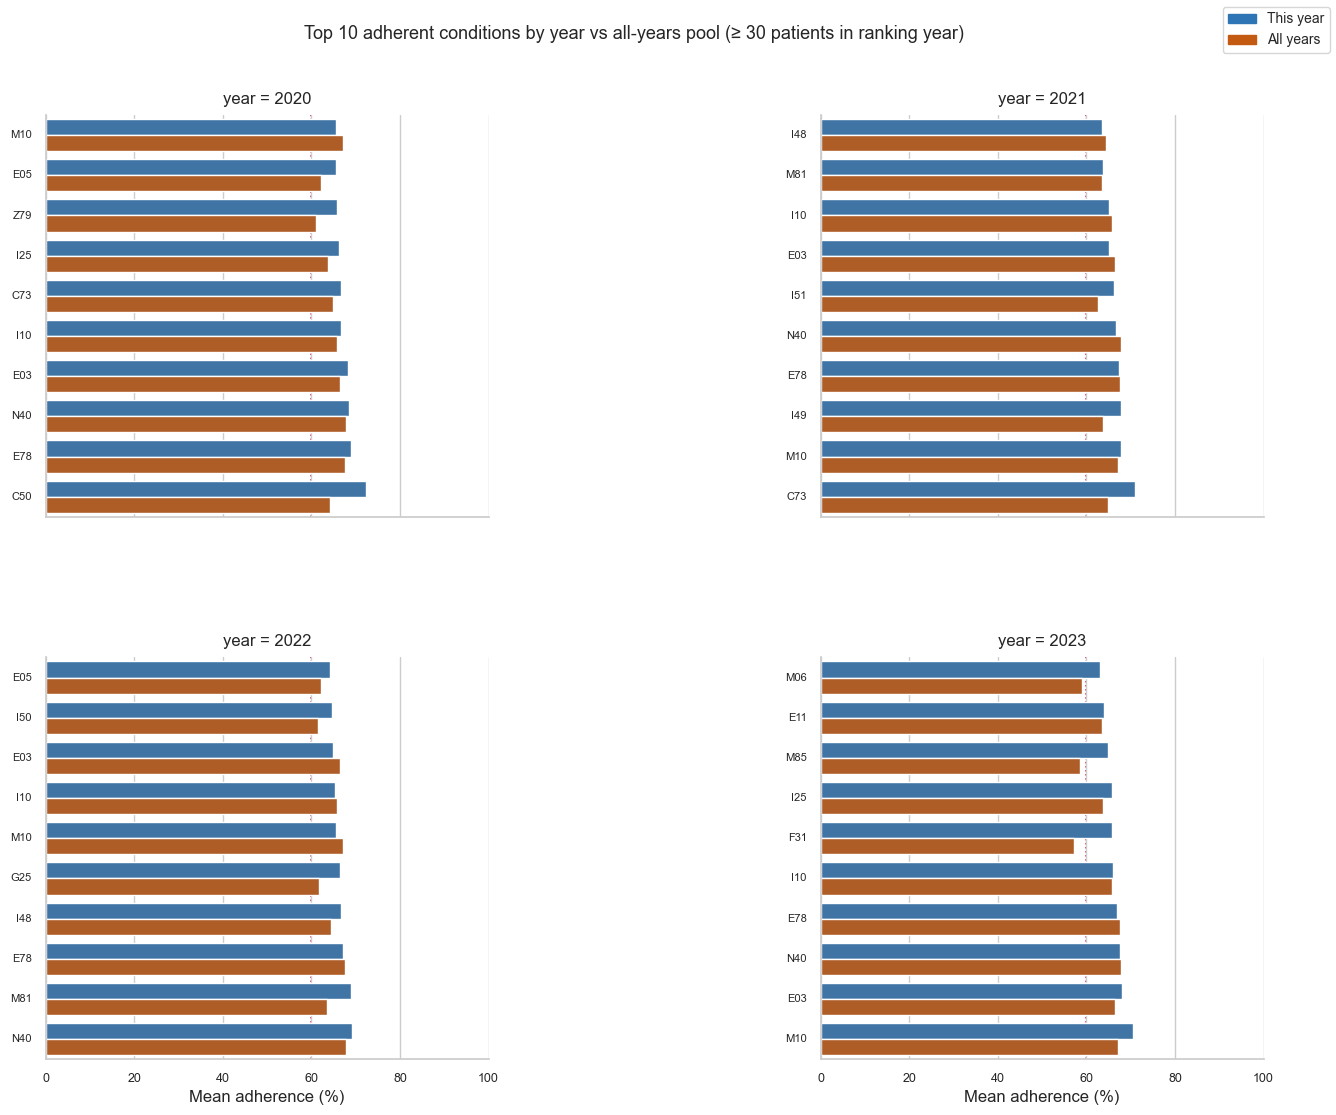


=== year = 2020 · top 10 ===


,condition,2020 %,n (2020),All years %,n (all),Δ (year − all)
0,C50,72.4,49,64.2,152,8.1
1,E78,68.9,2318,67.6,6035,1.4
2,N40,68.5,144,67.8,431,0.6
3,E03,68.2,566,66.4,1479,1.8
4,I10,66.7,3618,65.7,8566,0.9
5,C73,66.6,35,64.8,83,1.8
6,I25,66.2,308,63.7,721,2.5
7,Z79,65.7,155,61.0,446,4.8
8,E05,65.6,67,62.1,208,3.6
9,M10,65.6,180,67.1,402,-1.6



=== year = 2021 · top 10 ===


,condition,2021 %,n (2021),All years %,n (all),Δ (year − all)
10,C73,71.1,36,64.8,83,6.2
11,M10,67.9,190,67.1,402,0.8
12,I49,67.8,105,63.8,235,4.0
13,E78,67.4,2657,67.6,6035,-0.2
14,N40,66.6,186,67.8,431,-1.3
15,I51,66.1,68,62.7,158,3.4
16,E03,65.1,650,66.4,1479,-1.3
17,I10,65.0,3898,65.7,8566,-0.7
18,M81,63.7,77,63.6,167,0.1
19,I48,63.6,202,64.4,461,-0.8



=== year = 2022 · top 10 ===


,condition,2022 %,n (2022),All years %,n (all),Δ (year − all)
20,N40,69.1,157,67.8,431,1.3
21,M81,68.9,45,63.6,167,5.3
22,E78,67.1,2200,67.6,6035,-0.5
23,I48,66.6,151,64.4,461,2.2
24,G25,66.5,80,61.7,235,4.9
25,M10,65.7,134,67.1,402,-1.5
26,I10,65.2,3134,65.7,8566,-0.5
27,E03,65.0,527,66.4,1479,-1.4
28,I50,64.7,52,61.5,168,3.1
29,E05,64.1,79,62.1,208,2.0



=== year = 2023 · top 10 ===


,condition,2023 %,n (2023),All years %,n (all),Δ (year − all)
30,M10,70.5,100,67.1,402,3.4
31,E03,68.0,478,66.4,1479,1.5
32,N40,67.5,143,67.8,431,-0.3
33,E78,66.8,1900,67.6,6035,-0.8
34,I10,66.1,2505,65.7,8566,0.4
35,F31,65.8,83,57.2,305,8.6
36,I25,65.8,189,63.7,721,2.1
37,M85,64.9,39,58.5,123,6.4
38,E11,64.0,1259,63.6,3970,0.4
39,M06,63.1,101,58.9,278,4.1


In [98]:
# --- 2×2 seaborn grid: each year's top-10 conditions vs all-years mean ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MIN_N = 30
TOP_N = 10

# Prefer in-memory pair_all; else reload parquet
if "pair_all" not in globals() or pair_all is None or pair_all.empty:
    tables_all, _ = all_years_output_dirs()
    pair_all = pd.read_parquet(tables_all / "model_df_pair_all_years.parquet")
    print(f"loaded pair_all from parquet ({len(pair_all):,} rows)")

cond = pair_all[["DUPERSID", "YEAR", "ICD10CDX", "meps_adherence_ratio"]].copy()
cond = cond.dropna(subset=["meps_adherence_ratio", "ICD10CDX"])

# ICD labels
label_src = None
for cand in (
    Path(REPO) / "Notebooks/MEPS/output/all_years/tables/patient_drug_condition_bridge.parquet",
    Path(REPO) / "Notebooks/MEPS/output/all_years/tables/new_grouped_merge_df_chronic_drugs.parquet",
):
    if cand.exists():
        lab = pd.read_parquet(cand, columns=["ICD10CDX", "ICD10CDX_LABEL"]).dropna()
        label_src = lab.drop_duplicates("ICD10CDX")
        break
if label_src is not None:
    cond = cond.merge(label_src, on="ICD10CDX", how="left")
else:
    cond["ICD10CDX_LABEL"] = cond["ICD10CDX"].astype(str)
def _wrap_two_lines(text: str, width: int = 28) -> str:
    """Wrap a label onto at most 2 lines for readable y-tick text."""
    words = str(text).split()
    if not words:
        return ""
    line1, line2 = [], []
    for w in words:
        trial = (" ".join(line1 + [w])).strip()
        if not line2 and len(trial) <= width:
            line1.append(w)
        else:
            line2.append(w)
    a = " ".join(line1)
    b = " ".join(line2)
    if len(b) > width:
        b = b[: max(0, width - 1)].rstrip() + "…"
    return a if not b else f"{a}\n{b}"


cond["condition"] = (
    cond["ICD10CDX_LABEL"]
    .fillna(cond["ICD10CDX"].astype(str))
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
    .map(lambda s: _wrap_two_lines(s, width=28))
)

# Per-year and all-years condition stats
by_year = (
    cond.groupby(["YEAR", "condition"], as_index=False)
    .agg(
        mean_adherence=("meps_adherence_ratio", "mean"),
        n_patients=("DUPERSID", "nunique"),
    )
)
all_yrs = (
    cond.groupby("condition", as_index=False)
    .agg(
        all_years=("meps_adherence_ratio", "mean"),
        n_all=("DUPERSID", "nunique"),
    )
)

# Drop conditions with < MIN_N patients *in that year*, then take top TOP_N per year
eligible = by_year[by_year["n_patients"] >= MIN_N].copy()
print(
    f"conditions with ≥ {MIN_N} patients (person–years): "
    f"{len(eligible):,} / {len(by_year):,} year–condition rows"
)
print("kept per year:")
print(eligible.groupby("YEAR").size().to_string())

top_rows = []
for y in YEARS:
    sub = (
        eligible[eligible["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)
        .head(TOP_N)
    )
    top_rows.append(sub)
top = pd.concat(top_rows, ignore_index=True)
top = top.merge(all_yrs, on="condition", how="left")

# Long form for seaborn: two bars per condition
# Build in rank order within each year so catplot x-axis follows top-10 rank
pieces = []
for y in YEARS:
    block = (
        top[top["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)
        .reset_index(drop=True)
    )
    block["rank"] = np.arange(1, len(block) + 1)
    pieces.append(block)
top_ordered = pd.concat(pieces, ignore_index=True)

long = pd.concat(
    [
        top_ordered.assign(metric="This year", value=top_ordered["mean_adherence"]),
        top_ordered.assign(metric="All years", value=top_ordered["all_years"]),
    ],
    ignore_index=True,
)
long["year"] = long["YEAR"].astype(int)

sns.set_theme(style="whitegrid", context="notebook")

# Horizontal bars: condition on y-axis so long ICD labels stay readable
g = sns.FacetGrid(
    long,
    col="year",
    col_order=YEARS,
    col_wrap=2,
    sharex=True,
    sharey=False,
    height=5.6,
    aspect=1.25,
)

def _draw_panel(data, color=None, **kwargs):
    ax = plt.gca()
    y = int(data["year"].iloc[0])
    # Highest adherence at top
    order = (
        data[data["metric"] == "This year"]
        .sort_values("rank", ascending=False)["condition"]
        .tolist()
    )
    sns.barplot(
        data=data,
        y="condition",
        x="value",
        hue="metric",
        order=order,
        hue_order=["This year", "All years"],
        palette={"This year": "#2e75b6", "All years": "#c45911"},
        ax=ax,
        errorbar=None,
        orient="h",
    )
    ax.set_title(f"year = {y}", fontsize=12, pad=8)
    ax.set_xlabel("Mean adherence (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.axvline(60, color="crimson", linestyle=":", linewidth=1.1, zorder=0)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    # Give wrapped 2-line y labels room; avoid clipping into the neighbor panel
    ax.tick_params(axis="y", pad=4)
    for lab in ax.get_yticklabels():
        lab.set_linespacing(0.95)
        lab.set_verticalalignment("center")
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

g.map_dataframe(_draw_panel)
g.fig.subplots_adjust(top=0.90, hspace=0.35, wspace=0.75, left=0.08, right=0.95)
g.fig.suptitle(
    f"Top {TOP_N} adherent conditions by year vs all-years pool "
    f"(≥ {MIN_N} patients in ranking year)",
    fontsize=13,
)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#2e75b6", label="This year"),
    plt.Rectangle((0, 0), 1, 1, color="#c45911", label="All years"),
]
g.fig.legend(handles=handles, loc="upper right", frameon=True, fontsize=10)
plt.show()

# Compact table: one block per year
for y in YEARS:
    block = (
        top[top["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)[
            ["condition", "mean_adherence", "n_patients", "all_years", "n_all"]
        ]
        .assign(delta=lambda d: d["mean_adherence"] - d["all_years"])
        .rename(
            columns={
                "mean_adherence": f"{y} %",
                "n_patients": f"n ({y})",
                "all_years": "All years %",
                "n_all": "n (all)",
                "delta": "Δ (year − all)",
            }
        )
    )
    print(f"\n=== year = {y} · top {len(block)} ===")
    display(block.round(1))


## Step L — Training frame

Drop identifiers and the continuous adherence ratio from `model_df_all` (keep `is_adherent` as the label).


In [99]:
training_df = model_df_all.drop(
    columns=["DUPERSID", "YEAR", "meps_adherence_ratio"],
    errors="ignore",
).copy()

print(f"model_df_all: {model_df_all.shape[0]:,} rows × {model_df_all.shape[1]} cols")
print(f"training_df:  {training_df.shape[0]:,} rows × {training_df.shape[1]} cols")
print("dropped:", [c for c in ("DUPERSID", "YEAR", "meps_adherence_ratio") if c in model_df_all.columns])
training_df.head()


model_df_all: 28,691 rows × 319 cols
training_df:  28,691 rows × 316 cols
dropped: ['DUPERSID', 'YEAR', 'meps_adherence_ratio']


,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,POV_POOR,POV_NEAR_POOR,...,RXDRG_MTOR INHIBITORS,RXDRG_MULTIVITAMIN WITH MINERALS,RXDRG_OPHTHALMIC GLAUCOMA AGENTS,RXDRG_SGLT-2 INHIBITORS,RXDRG_SSRI ANTIDEPRESSANTS,RXDRG_VASODILATORS,ICD_F19,ICD_M72,RXDRG_ALPHA-ADRENORECEPTOR ANTAGONISTS,RXDRG_CHOLINERGIC AGONISTS,RXDRG_GLP-1 RECEPTOR AGONISTS,RXDRG_GROUP V ANTIARRHYTHMICS,RXDRG_ANTIANGINAL AGENTS,RXDRG_CGRP INHIBITORS,RXDRG_CROMOLYN OPHTHALMIC,RXDRG_DOCUSATE-SENNA,RXDRG_DUTASTERIDE,RXDRG_FIBRIC ACID DERIVATIVES,RXDRG_TIRZEPATIDE,ICD_U09
0,84,17000,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,85,18960,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,58,28920,1,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,72,28920,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,47,98788,1,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step M — Random Forest (`is_adherent`)

Same `PARAM_GRID` / `HalvingGridSearchCV` as `2023_clean.ipynb`, but a **person-level** holdout (not a random row split and not a year split): with `np.random.default_rng(42)`, sample **20% of unique `DUPERSID`s** for test; every row for those patients goes to test, all other patients' rows go to train. Features from `model_df_all` (drop `DUPERSID`, `YEAR`, `meps_adherence_ratio`, `n_drugs`, `n_conditions` from X; label = `is_adherent`). Confirms `len(set(train["DUPERSID"]) & set(test["DUPERSID"])) == 0`.


In [100]:
# ---- Modeling imports (same toolkit as 2023_clean) ----
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    HalvingGridSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
)
import matplotlib.pyplot as plt
import time


def plot_cm_with_recall(cm, ax, title, labels=("not adherent", "adherent"), cmap="Blues"):
    """2x2 confusion matrix with row-normalized recall + accuracy in title."""
    cm = np.asarray(cm)
    row_totals = cm.sum(axis=1, keepdims=True)
    pct = np.divide(
        cm * 100.0, row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals > 0,
    )
    acc = cm.trace() / cm.sum() * 100 if cm.sum() > 0 else 0.0

    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} (accuracy: {acc:.1f}%)")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(
                j, i, f"{int(cm[i, j])}\n({pct[i, j]:.1f}%)",
                ha="center", va="center", color=color, fontsize=11,
            )
    return ax


print("RF modeling helpers ready")


RF modeling helpers ready


In [101]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Same PARAM_GRID / CV settings as 2023_clean.ipynb — person-level split (not random rows).

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
RANDOM_STATE = 42
TEST_FRAC = 0.2

if "model_df_all" not in globals() or model_df_all is None or model_df_all.empty:
    tables_all, _ = all_years_output_dirs()
    model_df_all = pd.read_parquet(tables_all / "model_df_all_years.parquet")

rf_panel = model_df_all.copy()
unique_ids = rf_panel["DUPERSID"].drop_duplicates().to_numpy()
rng = np.random.default_rng(42)
n_test = int(round(TEST_FRAC * len(unique_ids)))
test_ids = set(rng.choice(unique_ids, size=n_test, replace=False).tolist())

train_rf = rf_panel[~rf_panel["DUPERSID"].isin(test_ids)].copy()
test_rf = rf_panel[rf_panel["DUPERSID"].isin(test_ids)].copy()

# Alias names used by overlap check / downstream cells
train = train_rf
test = test_rf

overlap = len(set(train["DUPERSID"]) & set(test["DUPERSID"]))
print(
    f"Step M person split: {len(unique_ids):,} unique DUPERSID | "
    f"test_ids={len(test_ids):,} ({TEST_FRAC:.0%}) | "
    f"train rows={len(train):,} | test rows={len(test):,}"
)
print(f"len(set(train['DUPERSID']) & set(test['DUPERSID'])) = {overlap}")
assert overlap == 0, f"person leakage: overlap={overlap}"
print("person-leakage check OK (overlap == 0)")

drop_from_X = [
    "DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio",
    "n_drugs", "n_conditions",
]

def _rf_X(df: pd.DataFrame) -> pd.DataFrame:
    X = df.drop(columns=[c for c in drop_from_X if c in df.columns]).copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    non_num = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    if non_num:
        raise TypeError(f"Non-numeric columns still in X: {non_num}")
    X = X.astype(np.float64)
    return X

X_train = _rf_X(train)
X_test = _rf_X(test)
X_test = X_test.reindex(columns=X_train.columns)
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

y_train = train["is_adherent"].astype(int)
y_test = test["is_adherent"].astype(int)

print(f"X shape: train {X_train.shape} | test {X_test.shape}")
print(f"class balance (train):\n{y_train.value_counts(normalize=True).round(3)}")
print(
    f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} "
    f"x {CV_FOLDS} folds"
)


Step M person split: 18,673 unique DUPERSID | test_ids=3,735 (20%) | train rows=22,960 | test rows=5,731
len(set(train['DUPERSID']) & set(test['DUPERSID'])) = 0
person-leakage check OK (overlap == 0)
X shape: train (22960, 313) | test (5731, 313)
class balance (train):
is_adherent
1    0.512
0    0.488
Name: proportion, dtype: float64
GridSearch combos: 432 x 5 folds


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 94
max_resources_: 22960
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 94
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 282
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 846
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 2538
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 7614
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 5
n_candidates: 2
n_resources: 22842
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Done in 40.2 minutes
Best params: {'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 

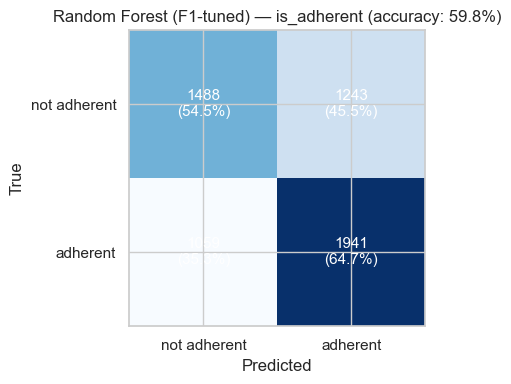

In [102]:
# HalvingGridSearchCV — F1-tuned (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(
    f"Iterations run: {search.n_iterations_} | "
    f"n_candidates per iter: {search.n_candidates_} | "
    f"n_resources per iter: {search.n_resources_}"
)

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "Random Forest (F1-tuned) — is_adherent")
plt.tight_layout()
plt.show()

best_params = {k: best_rf.get_params()[k] for k in PARAM_GRID if k in best_rf.get_params()}
best_score = float(search.best_score_)


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 94
max_resources_: 22960
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 432
n_resources: 94
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
----------
iter: 1
n_candidates: 144
n_resources: 282
Fitting 5 folds for each of 144 candidates, totalling 720 fits
----------
iter: 2
n_candidates: 48
n_resources: 846
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 3
n_candidates: 16
n_resources: 2538
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 4
n_candidates: 6
n_resources: 7614
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 5
n_candidates: 2
n_resources: 22842
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Done in 25.7 minutes
Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estim

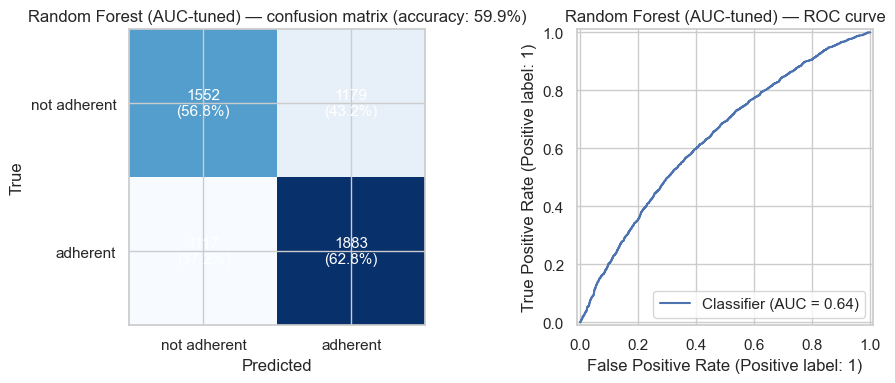

In [103]:
# HalvingGridSearchCV — AUC-tuned (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search_auc = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search_auc.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search_auc.best_params_)
print(f"Best CV roc_auc: {search_auc.best_score_:.4f}")
print(
    f"Iterations run: {search_auc.n_iterations_} | "
    f"n_candidates per iter: {search_auc.n_candidates_} | "
    f"n_resources per iter: {search_auc.n_resources_}"
)

best_rf_auc = search_auc.best_estimator_
y_pred_auc = best_rf_auc.predict(X_test)
y_proba_auc = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba_auc):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_auc, digits=3))

cm_auc = confusion_matrix(y_test, y_pred_auc)
print("Confusion matrix (test set):")
print(cm_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(cm_auc, axes[0], "Random Forest (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
axes[1].set_title("Random Forest (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()

best_params_auc = {
    k: best_rf_auc.get_params()[k] for k in PARAM_GRID if k in best_rf_auc.get_params()
}
best_score_auc = float(search_auc.best_score_)


Gini importance — top 20 (AUC-tuned RF)


,gini_importance
AGE,0.084131
FAMINC,0.064935
PATIENT_COST_SHARE,0.057486
ICD_E78,0.035532
ICD_I10,0.027221
RXDRG_ATORVASTATIN,0.020276
WHITE,0.012956
RXDRG_LEVOTHYROXINE,0.012122
RXDRG_LISINOPRIL,0.011560
RXDRG_METOPROLOL,0.010976


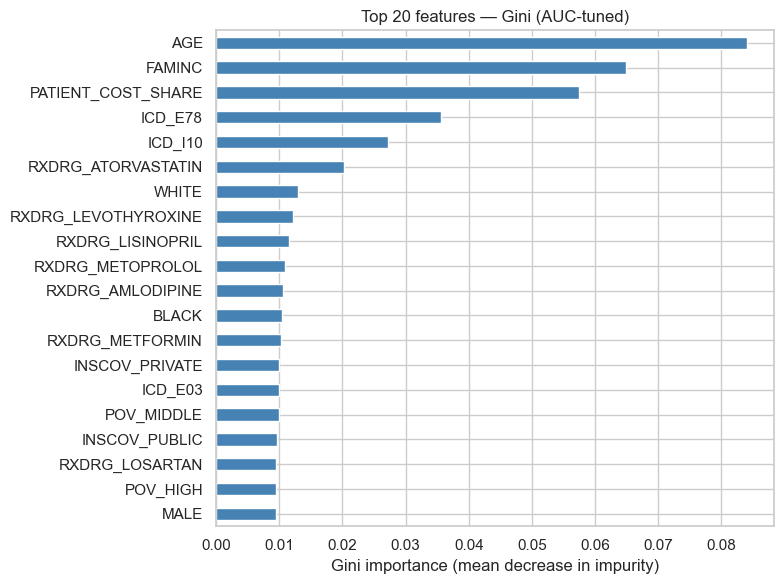

In [104]:
# Feature importance (Gini) — prefer AUC-tuned model when available

model_for_imp = best_rf_auc if "best_rf_auc" in dir() else best_rf
model_label = (
    "AUC-tuned"
    if "best_rf_auc" in dir() and model_for_imp is best_rf_auc
    else "F1-tuned"
)

TOP_N = 20

gini_imp = (
    pd.Series(model_for_imp.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N} ({model_label} RF)")
display(gini_imp.head(TOP_N).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N} features — Gini ({model_label})")
plt.tight_layout()
plt.show()


In [105]:
# Predict is_adherent on holdout (or any feature frame with the same columns)

def predict_adherence(features: pd.DataFrame, model=None, threshold: float = 0.5):
    """Return predicted label + P(adherent) using the tuned RF.

    ``features`` must include the same columns as ``X_train`` (extra columns
    are ignored; missing columns raise).
    """
    model = model or (best_rf_auc if "best_rf_auc" in dir() else best_rf)
    cols = list(X_train.columns)
    missing = [c for c in cols if c not in features.columns]
    if missing:
        raise KeyError(f"Missing feature columns: {missing[:10]}{'...' if len(missing) > 10 else ''}")
    X_new = features[cols].copy()
    if "AGE" in X_new.columns:
        X_new["AGE"] = pd.to_numeric(X_new["AGE"], errors="coerce")
    X_new = X_new.astype(np.float64).fillna(X_train.median(numeric_only=True))
    proba = model.predict_proba(X_new)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pd.DataFrame({"is_adherent_pred": pred, "p_adherent": proba}, index=features.index)


# Demo on the held-out test set
pred_test = predict_adherence(X_test)
pred_test["is_adherent_true"] = y_test.to_numpy()
print(pred_test.head(10))
print(
    "\nHoldout accuracy:",
    float((pred_test["is_adherent_pred"] == pred_test["is_adherent_true"]).mean()),
)


    is_adherent_pred  p_adherent  is_adherent_true
8                  1    0.520018                 0
17                 1    0.613160                 0
20                 0    0.496114                 1
21                 1    0.636971                 1
26                 0    0.453851                 0
27                 0    0.439137                 1
28                 1    0.531168                 1
38                 0    0.436337                 0
48                 0    0.459140                 0
51                 0    0.428875                 1

Holdout accuracy: 0.5983248996684697


## Step N — XGBoost (`is_adherent`)

Same recipe as `2023_clean.ipynb` cells 101–105: drop drug-name one-hots (`RXDRG_*`, analogous to dropping `RX_*`), keep `n_drugs` / `n_conditions` + ICD + demographics, then `HalvingGridSearchCV` on the full `XGB_PARAM_GRID` (F1-tuned, then AUC-tuned).


In [106]:
# XGBoost: predict is_adherent (no RXDRG_* dummies)
# Same XGB_PARAM_GRID / CV settings as 2023_clean.ipynb.
# If import fails on macOS with libomp.dylib missing, run: brew install libomp

from xgboost import XGBClassifier

XGB_PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1.0, 5.0],
}

CV_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Mirror model_df_no_rx: drop drug-name one-hots (RXDRG_* here; RX_* in 2023)
rxdrg_cols = [c for c in training_df.columns if c.startswith("RXDRG_")]
training_df_no_rx = training_df.drop(columns=rxdrg_cols).copy()

drop_cols_xgb = ["is_adherent"]  # DUPERSID / YEAR / meps_adherence_ratio already gone

X_xgb = training_df_no_rx.drop(
    columns=[c for c in drop_cols_xgb if c in training_df_no_rx.columns]
).copy()
y_xgb = training_df_no_rx["is_adherent"].astype(int)

if "AGE" in X_xgb.columns:
    X_xgb["AGE"] = pd.to_numeric(X_xgb["AGE"], errors="coerce")

non_num = X_xgb.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_num:
    raise TypeError(f"Non-numeric columns still in X_xgb: {non_num}")

X_xgb = X_xgb.astype(np.float32)
# XGBoost sentinel for missing (matches 2023 Model builders using -999)
X_xgb = X_xgb.fillna(-999.0)

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_xgb
)

neg, pos = np.bincount(y_train_xgb.astype(int))
scale_pos_weight = neg / pos if pos > 0 else 1.0

print(
    f"X_xgb shape: {X_xgb.shape} | train: {X_train_xgb.shape[0]} | "
    f"test: {X_test_xgb.shape[0]}"
)
print(f"dropped RXDRG_* cols: {len(rxdrg_cols)}")
print(f"class balance (train):\n{y_train_xgb.value_counts(normalize=True).round(3)}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(
    f"Grid combos: {np.prod([len(v) for v in XGB_PARAM_GRID.values()])} "
    f"x {CV_FOLDS} folds"
)
print(f"features sample: {X_xgb.columns.tolist()[:15]}...")


X_xgb shape: (28691, 99) | train: 22952 | test: 5739
dropped RXDRG_* cols: 216
class balance (train):
is_adherent
1    0.514
0    0.486
Name: proportion, dtype: float64
scale_pos_weight: 0.946
Grid combos: 576 x 5 folds
features sample: ['AGE', 'FAMINC', 'INSCOV_PRIVATE', 'INSCOV_PUBLIC', 'INSCOV_UNINSURED', 'MALE', 'FEMALE', 'WHITE', 'BLACK', 'AMER_INDIAN', 'ASIAN_INDIAN', 'CHINESE', 'FILIPINO', 'PMED_DELAY_COST', 'NO_PMED_DELAY_COST']...


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 94
max_resources_: 22952
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 94
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 282
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 846
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 2538
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 7614
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 5
n_candidates: 3
n_resources: 22842
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Done in 2.3 minutes
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5.0,

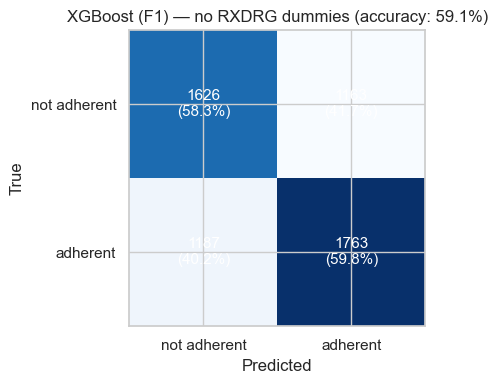

In [107]:
# HalvingGridSearchCV — F1-tuned XGBoost (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search_xgb = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search_xgb.fit(X_train_xgb, y_train_xgb)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search_xgb.best_params_)
print(f"Best CV f1: {search_xgb.best_score_:.4f}")
print(
    f"Iterations run: {search_xgb.n_iterations_} | "
    f"n_candidates per iter: {search_xgb.n_candidates_} | "
    f"n_resources per iter: {search_xgb.n_resources_}"
)

best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_xgb)
print("\nClassification report (test set):")
print(classification_report(y_test_xgb, y_pred_xgb, digits=3))

cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
print("Confusion matrix (test set):")
print(cm_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm_xgb, ax, "XGBoost (F1) — no RXDRG dummies")
plt.tight_layout()
plt.show()

best_params_xgb = {
    k: best_xgb.get_params()[k] for k in XGB_PARAM_GRID if k in best_xgb.get_params()
}
best_score_xgb = float(search_xgb.best_score_)


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 94
max_resources_: 22952
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 576
n_resources: 94
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
----------
iter: 1
n_candidates: 192
n_resources: 282
Fitting 5 folds for each of 192 candidates, totalling 960 fits
----------
iter: 2
n_candidates: 64
n_resources: 846
Fitting 5 folds for each of 64 candidates, totalling 320 fits
----------
iter: 3
n_candidates: 22
n_resources: 2538
Fitting 5 folds for each of 22 candidates, totalling 110 fits
----------
iter: 4
n_candidates: 8
n_resources: 7614
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 5
n_candidates: 3
n_resources: 22842
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Done in 2.3 minutes
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 5.0,

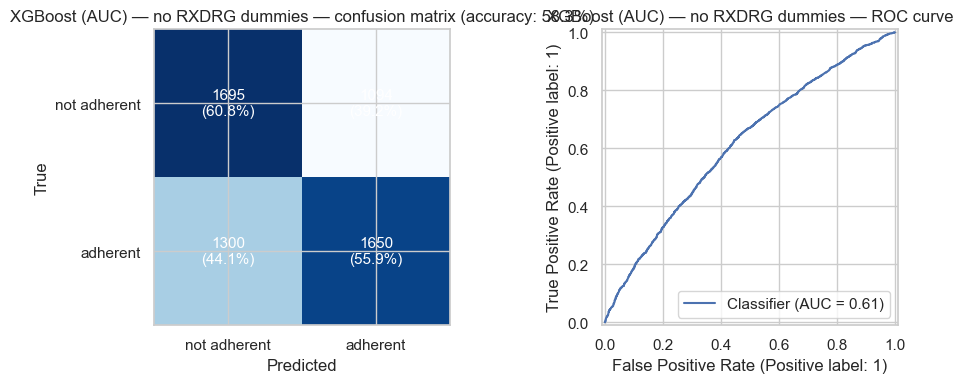

In [108]:
# HalvingGridSearchCV — AUC-tuned XGBoost (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search_xgb_auc = HalvingGridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        verbosity=0,
    ),
    param_grid=XGB_PARAM_GRID,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search_xgb_auc.fit(X_train_xgb, y_train_xgb)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search_xgb_auc.best_params_)
print(f"Best CV roc_auc: {search_xgb_auc.best_score_:.4f}")
print(
    f"Iterations run: {search_xgb_auc.n_iterations_} | "
    f"n_candidates per iter: {search_xgb_auc.n_candidates_} | "
    f"n_resources per iter: {search_xgb_auc.n_resources_}"
)

best_xgb_auc = search_xgb_auc.best_estimator_
y_pred_xgb_auc = best_xgb_auc.predict(X_test_xgb)
y_proba_xgb_auc = best_xgb_auc.predict_proba(X_test_xgb)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test_xgb, y_proba_xgb_auc):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test_xgb, y_pred_xgb_auc, digits=3))

cm_xgb_auc = confusion_matrix(y_test_xgb, y_pred_xgb_auc)
print("Confusion matrix (test set):")
print(cm_xgb_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(
    cm_xgb_auc, axes[0], "XGBoost (AUC) — no RXDRG dummies — confusion matrix"
)
RocCurveDisplay.from_predictions(y_test_xgb, y_proba_xgb_auc, ax=axes[1])
axes[1].set_title("XGBoost (AUC) — no RXDRG dummies — ROC curve")
plt.tight_layout()
plt.show()

best_params_xgb_auc = {
    k: best_xgb_auc.get_params()[k]
    for k in XGB_PARAM_GRID
    if k in best_xgb_auc.get_params()
}
best_score_xgb_auc = float(search_xgb_auc.best_score_)


Gain importance — top 20 (AUC-tuned XGBoost)
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 5.0}


,gain_importance
ICD_E78,0.208574
n_drugs,0.105538
ICD_I10,0.061864
n_conditions,0.057464
AGE,0.056349
ICD_J45,0.042867
ICD_J30,0.032636
BLACK,0.028788
ICD_E03,0.027482
WHITE,0.027479


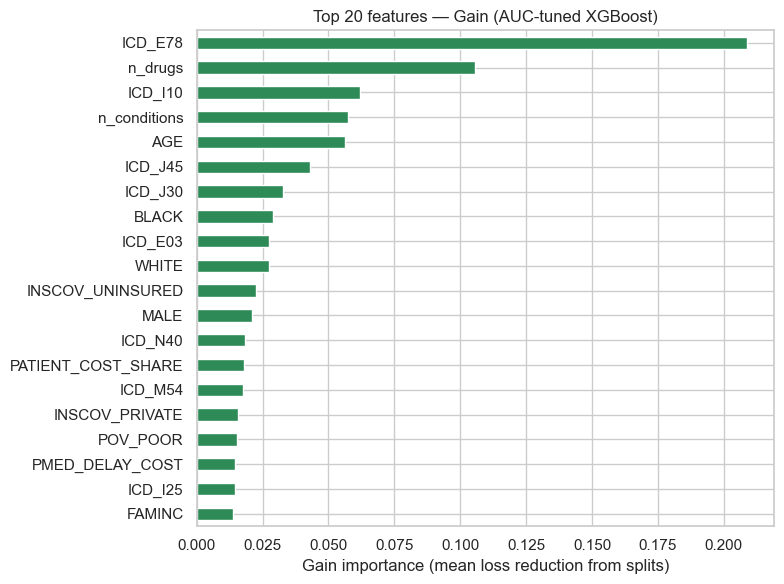

In [109]:
# XGBoost feature importance — Gain (prefer AUC-tuned when available)

model_xgb_imp = best_xgb_auc if "best_xgb_auc" in dir() else best_xgb
model_xgb_label = (
    "AUC-tuned"
    if "best_xgb_auc" in dir() and model_xgb_imp is best_xgb_auc
    else "F1-tuned"
)

TOP_N_XGB = 20

gain_imp_xgb = (
    pd.Series(model_xgb_imp.feature_importances_, index=X_train_xgb.columns)
    .sort_values(ascending=False)
)

_p_xgb = model_xgb_imp.get_params()
_tuned_xgb = {k: _p_xgb[k] for k in XGB_PARAM_GRID if k in _p_xgb}

print(f"Gain importance — top {TOP_N_XGB} ({model_xgb_label} XGBoost)")
print("Best params:", _tuned_xgb)
display(gain_imp_xgb.head(TOP_N_XGB).to_frame("gain_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gain_imp_xgb.head(TOP_N_XGB).iloc[::-1].plot(kind="barh", ax=ax, color="seagreen")
ax.set_xlabel("Gain importance (mean loss reduction from splits)")
ax.set_title(f"Top {TOP_N_XGB} features — Gain ({model_xgb_label} XGBoost)")
plt.tight_layout()
plt.show()


SHAP mean |value| — top 20 (AUC-tuned XGBoost, n=500)


,mean_abs_shap
ICD_E78,0.118358
n_drugs,0.095641
AGE,0.081229
ICD_I10,0.067542
n_conditions,0.035744
BLACK,0.026852
ICD_J45,0.019218
WHITE,0.018129
ICD_E03,0.013626
MALE,0.006178


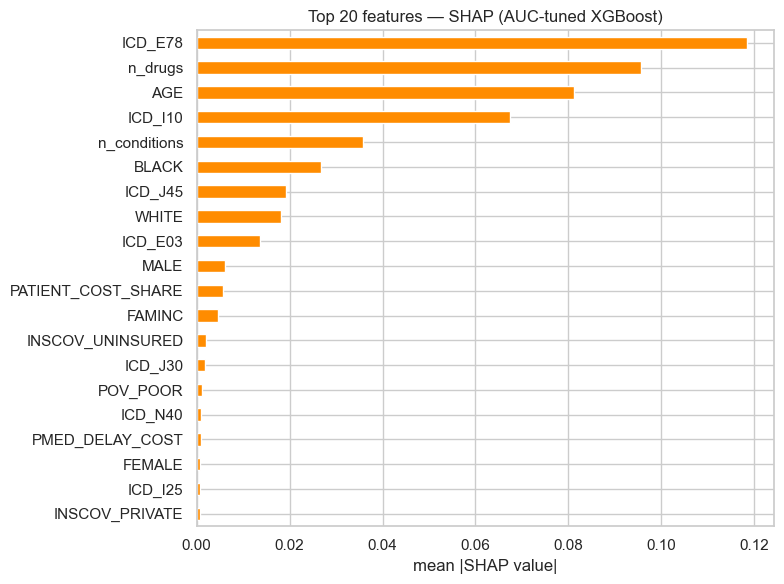

SHAP beeswarm (class = adherent):


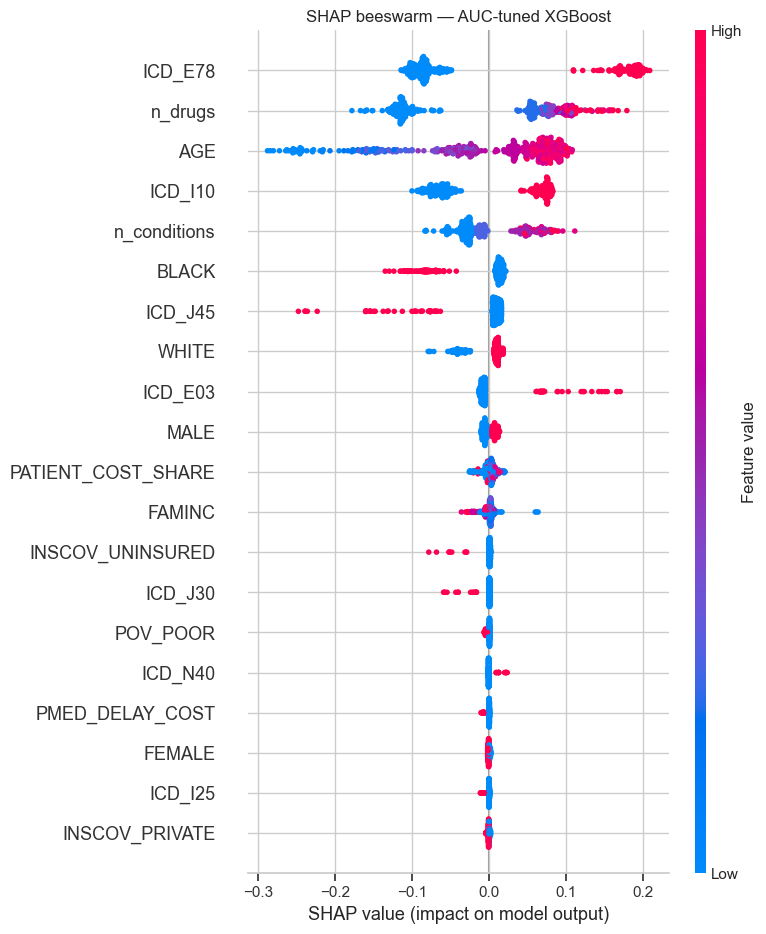

In [110]:
# XGBoost — SHAP (optional; skip gracefully if shap is not installed)

SHAP_SAMPLE_XGB = 500

try:
    import shap
except ImportError:
    print("shap not installed — skip SHAP cell (pip install shap)")
else:
    X_shap_xgb = X_train_xgb.sample(
        n=min(SHAP_SAMPLE_XGB, len(X_train_xgb)), random_state=RANDOM_STATE
    )
    explainer_xgb = shap.TreeExplainer(model_xgb_imp)
    shap_values_xgb = explainer_xgb.shap_values(X_shap_xgb)

    if isinstance(shap_values_xgb, list):
        shap_pos_xgb = shap_values_xgb[1]
    elif getattr(shap_values_xgb, "ndim", 0) == 3:
        shap_pos_xgb = shap_values_xgb[:, :, 1]
    else:
        shap_pos_xgb = shap_values_xgb

    mean_abs_shap_xgb = (
        pd.Series(np.abs(shap_pos_xgb).mean(axis=0), index=X_shap_xgb.columns)
        .sort_values(ascending=False)
    )

    print(
        f"SHAP mean |value| — top {TOP_N_XGB} "
        f"({model_xgb_label} XGBoost, n={len(X_shap_xgb)})"
    )
    display(mean_abs_shap_xgb.head(TOP_N_XGB).to_frame("mean_abs_shap"))

    fig, ax = plt.subplots(figsize=(8, 6))
    mean_abs_shap_xgb.head(TOP_N_XGB).iloc[::-1].plot(
        kind="barh", ax=ax, color="darkorange"
    )
    ax.set_xlabel("mean |SHAP value|")
    ax.set_title(f"Top {TOP_N_XGB} features — SHAP ({model_xgb_label} XGBoost)")
    plt.tight_layout()
    plt.show()

    print("SHAP beeswarm (class = adherent):")
    shap.summary_plot(shap_pos_xgb, X_shap_xgb, max_display=TOP_N_XGB, show=False)
    plt.title(f"SHAP beeswarm — {model_xgb_label} XGBoost")
    plt.tight_layout()
    plt.show()


In [111]:
# Predict is_adherent with the tuned XGBoost

def predict_adherence_xgb(features: pd.DataFrame, model=None, threshold: float = 0.5):
    """Return predicted label + P(adherent) using the tuned XGBoost.

    ``features`` should match ``X_train_xgb`` columns (no RXDRG_* needed).
    """
    model = model or (best_xgb_auc if "best_xgb_auc" in dir() else best_xgb)
    cols = list(X_train_xgb.columns)
    missing = [c for c in cols if c not in features.columns]
    if missing:
        raise KeyError(
            f"Missing feature columns: {missing[:10]}"
            f"{'...' if len(missing) > 10 else ''}"
        )
    X_new = features[cols].copy()
    if "AGE" in X_new.columns:
        X_new["AGE"] = pd.to_numeric(X_new["AGE"], errors="coerce")
    X_new = X_new.astype(np.float32).fillna(-999.0)
    proba = model.predict_proba(X_new)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pd.DataFrame(
        {"is_adherent_pred": pred, "p_adherent": proba}, index=features.index
    )


pred_test_xgb = predict_adherence_xgb(X_test_xgb)
pred_test_xgb["is_adherent_true"] = y_test_xgb.to_numpy()
print(pred_test_xgb.head(10))
print(
    "\nHoldout accuracy:",
    float(
        (pred_test_xgb["is_adherent_pred"] == pred_test_xgb["is_adherent_true"]).mean()
    ),
)


       is_adherent_pred  p_adherent  is_adherent_true
7625                  0    0.262464                 0
2989                  0    0.462751                 0
21620                 1    0.699323                 1
16651                 1    0.530173                 0
7428                  0    0.475012                 1
12261                 0    0.440499                 0
17094                 1    0.554379                 0
27465                 0    0.453356                 1
7664                  1    0.510291                 1
23568                 1    0.568614                 1

Holdout accuracy: 0.5905209966893187


## Step O — Year-to-year adherence persistence

For patients present in **consecutive calendar years** (e.g. 2020 and 2021):

1. If adherent in year *Y*, how often are they adherent in *Y+1*?
2. If non-adherent in year *Y*, how often are they non-adherent in *Y+1*?
3. Correlation between adherence status (and continuous ratio) in *Y* vs *Y+1*.

Unit of analysis: one row per `(DUPERSID, year_Y → year_Y+1)` from `model_df_all` (patient–year grain). Only true consecutive years (gap years excluded).


In [112]:
# Build consecutive-year adherence pairs from the patient–year panel

if "model_df_all" not in globals() or model_df_all is None or model_df_all.empty:
    tables_all, _ = all_years_output_dirs()
    model_df_all = pd.read_parquet(tables_all / "model_df_all_years.parquet")
    print(f"loaded model_df_all from parquet ({len(model_df_all):,} rows)")

cols = ["DUPERSID", "YEAR", "is_adherent"]
if "meps_adherence_ratio" in model_df_all.columns:
    cols.append("meps_adherence_ratio")

panel = (
    model_df_all[cols]
    .drop_duplicates(["DUPERSID", "YEAR"])
    .sort_values(["DUPERSID", "YEAR"])
    .copy()
)
panel["is_adherent"] = panel["is_adherent"].astype(int)
panel["year_next"] = panel["YEAR"] + 1

right = panel.drop(columns=["year_next"]).rename(
    columns={
        "YEAR": "year_y1",
        "is_adherent": "is_adherent_y1",
        **(
            {"meps_adherence_ratio": "meps_adherence_ratio_y1"}
            if "meps_adherence_ratio" in panel.columns
            else {}
        ),
    }
)
left = panel.rename(
    columns={
        "YEAR": "year_y",
        "is_adherent": "is_adherent_y",
        **(
            {"meps_adherence_ratio": "meps_adherence_ratio_y"}
            if "meps_adherence_ratio" in panel.columns
            else {}
        ),
    }
)

pairs = left.merge(
    right,
    left_on=["DUPERSID", "year_next"],
    right_on=["DUPERSID", "year_y1"],
    how="inner",
).drop(columns=["year_next"])

n_multi = panel.groupby("DUPERSID")["YEAR"].nunique()
print(f"patient–year rows: {len(panel):,}")
print(f"patients in ≥2 years (any years): {(n_multi >= 2).sum():,}")
print(f"consecutive (Y → Y+1) pairs: {len(pairs):,}")
print("pairs by starting year Y:")
display(pairs.groupby("year_y").size().rename("n_pairs"))
display(pairs.head())


patient–year rows: 28,691
patients in ≥2 years (any years): 8,847
consecutive (Y → Y+1) pairs: 9,919
pairs by starting year Y:


year_y
2020    4753
2021    3174
2022    1992
Name: n_pairs, dtype: int64

,DUPERSID,year_y,is_adherent_y,meps_adherence_ratio_y,year_y1,is_adherent_y1,meps_adherence_ratio_y1
0,2320013101,2020,0,34.246575,2021,0,53.357653
1,2320018101,2020,1,78.767123,2021,0,57.534247
2,2320018102,2020,1,65.703611,2021,1,73.972603
3,2320024101,2020,1,90.410959,2021,0,58.219178
4,2320025101,2020,0,21.917808,2021,0,57.534247


In [113]:
# Transition rates: adherent→adherent and non-adherent→non-adherent

# Labels for readability
pairs = pairs.copy()
pairs["status_y"] = np.where(pairs["is_adherent_y"] == 1, "adherent", "non-adherent")
pairs["status_y1"] = np.where(pairs["is_adherent_y1"] == 1, "adherent", "non-adherent")

# Contingency table (counts + row %)
ct = pd.crosstab(pairs["status_y"], pairs["status_y1"], margins=True)
ct_pct = pd.crosstab(pairs["status_y"], pairs["status_y1"], normalize="index") * 100

print("Transition counts (rows = year Y, cols = year Y+1):")
display(ct)
print("Row % (persistence / switching given year-Y status):")
display(ct_pct.round(1))

# Explicit answers to the two questions
n_adh_y = int((pairs["is_adherent_y"] == 1).sum())
n_adh_persist = int(((pairs["is_adherent_y"] == 1) & (pairs["is_adherent_y1"] == 1)).sum())
n_non_y = int((pairs["is_adherent_y"] == 0).sum())
n_non_persist = int(((pairs["is_adherent_y"] == 0) & (pairs["is_adherent_y1"] == 0)).sum())

print(
    f"\nIf adherent in Y → still adherent in Y+1: "
    f"{n_adh_persist:,} / {n_adh_y:,} ({100 * n_adh_persist / n_adh_y if n_adh_y else 0:.1f}%)"
)
print(
    f"If non-adherent in Y → still non-adherent in Y+1: "
    f"{n_non_persist:,} / {n_non_y:,} ({100 * n_non_persist / n_non_y if n_non_y else 0:.1f}%)"
)

# Overall agreement (same status both years)
n_same = int((pairs["is_adherent_y"] == pairs["is_adherent_y1"]).sum())
print(
    f"Same status both years: {n_same:,} / {len(pairs):,} "
    f"({100 * n_same / len(pairs):.1f}%)"
)

# By calendar transition (2020→2021, 2021→2022, 2022→2023)
by_year = (
    pairs.assign(transition=pairs["year_y"].astype(str) + "→" + pairs["year_y1"].astype(str))
    .groupby("transition")
    .apply(
        lambda g: pd.Series({
            "n_pairs": len(g),
            "adh_Y_persist_%": 100 * ((g["is_adherent_y"] == 1) & (g["is_adherent_y1"] == 1)).sum()
                / max((g["is_adherent_y"] == 1).sum(), 1),
            "non_Y_persist_%": 100 * ((g["is_adherent_y"] == 0) & (g["is_adherent_y1"] == 0)).sum()
                / max((g["is_adherent_y"] == 0).sum(), 1),
            "same_status_%": 100 * (g["is_adherent_y"] == g["is_adherent_y1"]).mean(),
        }),
        include_groups=False,
    )
)
print("\nPersistence by calendar transition:")
display(by_year.round(1))


Transition counts (rows = year Y, cols = year Y+1):


status_y1,adherent,non-adherent,All
status_y,,,
adherent,3521,2164,5685
non-adherent,1727,2507,4234
All,5248,4671,9919


Row % (persistence / switching given year-Y status):


status_y1,adherent,non-adherent
status_y,,
adherent,61.9,38.1
non-adherent,40.8,59.2



If adherent in Y → still adherent in Y+1: 3,521 / 5,685 (61.9%)
If non-adherent in Y → still non-adherent in Y+1: 2,507 / 4,234 (59.2%)
Same status both years: 6,028 / 9,919 (60.8%)

Persistence by calendar transition:


,n_pairs,adh_Y_persist_%,non_Y_persist_%,same_status_%
transition,,,,
2020→2021,4753.0,63.0,59.7,61.7
2021→2022,3174.0,60.1,58.5,59.4
2022→2023,1992.0,62.0,59.2,60.8


Binary is_adherent (Y vs Y+1)
  Pearson r / phi: 0.2095  (p=7.78e-99)
  Spearman rho:    0.2095  (p=7.78e-99)
  Odds ratio (adh_Y → adh_Y1 vs non→adh): 2.362
  2x2 counts: a(adh→adh)=3,521  b(adh→non)=2,164  c(non→adh)=1,727  d(non→non)=2,507

Continuous meps_adherence_ratio (Y vs Y+1), n=9,919
  Pearson r:    0.2655  (p=1.06e-159)
  Spearman rho: 0.2633  (p=5.38e-157)


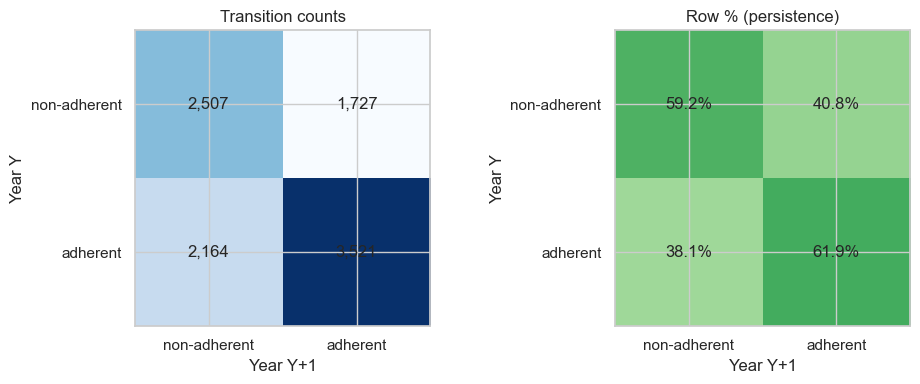

In [114]:
# Correlation: prior-year adherence vs next-year adherence

from scipy import stats

x = pairs["is_adherent_y"].astype(float)
y = pairs["is_adherent_y1"].astype(float)

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)
# Phi coefficient for 2x2 binary == Pearson on 0/1
phi = pearson_r

# Odds ratio from 2x2 table (adherent coded 1)
a = int(((pairs["is_adherent_y"] == 1) & (pairs["is_adherent_y1"] == 1)).sum())
b = int(((pairs["is_adherent_y"] == 1) & (pairs["is_adherent_y1"] == 0)).sum())
c = int(((pairs["is_adherent_y"] == 0) & (pairs["is_adherent_y1"] == 1)).sum())
d = int(((pairs["is_adherent_y"] == 0) & (pairs["is_adherent_y1"] == 0)).sum())
odds_ratio = (a * d) / (b * c) if b > 0 and c > 0 else np.nan

print("Binary is_adherent (Y vs Y+1)")
print(f"  Pearson r / phi: {pearson_r:.4f}  (p={pearson_p:.2e})")
print(f"  Spearman rho:    {spearman_r:.4f}  (p={spearman_p:.2e})")
print(f"  Odds ratio (adh_Y → adh_Y1 vs non→adh): {odds_ratio:.3f}")
print(f"  2x2 counts: a(adh→adh)={a:,}  b(adh→non)={b:,}  c(non→adh)={c:,}  d(non→non)={d:,}")

# Continuous ratio correlation when available
if {"meps_adherence_ratio_y", "meps_adherence_ratio_y1"} <= set(pairs.columns):
    cont = pairs.dropna(subset=["meps_adherence_ratio_y", "meps_adherence_ratio_y1"])
    r_c, p_c = stats.pearsonr(cont["meps_adherence_ratio_y"], cont["meps_adherence_ratio_y1"])
    rho_c, p_rho = stats.spearmanr(cont["meps_adherence_ratio_y"], cont["meps_adherence_ratio_y1"])
    print(f"\nContinuous meps_adherence_ratio (Y vs Y+1), n={len(cont):,}")
    print(f"  Pearson r:    {r_c:.4f}  (p={p_c:.2e})")
    print(f"  Spearman rho: {rho_c:.4f}  (p={p_rho:.2e})")

# Simple heatmap of transition probabilities
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# counts heatmap
mat = pd.crosstab(pairs["status_y"], pairs["status_y1"]).reindex(
    index=["non-adherent", "adherent"], columns=["non-adherent", "adherent"]
)
im0 = axes[0].imshow(mat.values, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(mat.columns)
axes[0].set_yticklabels(mat.index)
axes[0].set_xlabel("Year Y+1")
axes[0].set_ylabel("Year Y")
axes[0].set_title("Transition counts")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{int(mat.values[i, j]):,}", ha="center", va="center")

mat_p = pd.crosstab(pairs["status_y"], pairs["status_y1"], normalize="index").reindex(
    index=["non-adherent", "adherent"], columns=["non-adherent", "adherent"]
)
im1 = axes[1].imshow(mat_p.values, cmap="Greens", vmin=0, vmax=1)
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(mat_p.columns)
axes[1].set_yticklabels(mat_p.index)
axes[1].set_xlabel("Year Y+1")
axes[1].set_ylabel("Year Y")
axes[1].set_title("Row % (persistence)")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{100 * mat_p.values[i, j]:.1f}%", ha="center", va="center")

plt.tight_layout()
plt.show()


## Step P — Prior-year features (4-lag merge, no same-year leakage)

1. Load `model_df_all_years.parquet` (**28,691** rows).
2. Build prior frame with `is_adherent`, `meps_adherence_ratio`, `n_drugs`, `n_conditions`; rename to `prior_is_adherent`, `prior_ratio`, `prior_n_drugs`, `prior_n_cond`; `prior["YEAR"] += 1`; merge on `DUPERSID`+`YEAR` (`how="inner"`).
3. Expect **9,919** rows / **8,748** patients; usable X = **315** without priors, **319** with the four priors.
4. **Time split:** train **2021–2022** (7,927), test **2023** (1,992). Run **DUPERSID overlap** check.
5. Print 2023 majority baseline (~53.0%), then AUC for `prior_is_adherent` alone (baseline **0.6044**) vs all **four** prior features.


In [115]:
# Prior-year lag: 4 features, time split, overlap check, AUC comparison

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

tables_all, _ = all_years_output_dirs()
panel_path = tables_all / "model_df_all_years.parquet"
model_df_all = pd.read_parquet(panel_path)
print(f"loaded {panel_path}")
print(
    f"raw panel: {len(model_df_all):,} rows | "
    f"{model_df_all['DUPERSID'].nunique():,} patients"
)

PRIOR_MAP = {
    "is_adherent": "prior_is_adherent",
    "meps_adherence_ratio": "prior_ratio",
    "n_drugs": "prior_n_drugs",
    "n_conditions": "prior_n_cond",
}
prior = model_df_all[["DUPERSID", "YEAR", *PRIOR_MAP.keys()]].copy()
prior = prior.rename(columns=PRIOR_MAP)
prior["YEAR"] += 1

lagged = model_df_all.merge(prior, on=["DUPERSID", "YEAR"], how="inner")
PRIOR_COLS = list(PRIOR_MAP.values())

n_rows = len(lagged)
n_patients = lagged["DUPERSID"].nunique()
print(f"\nAfter prior-year merge: {n_rows:,} rows | {n_patients:,} patients")
assert n_rows == 9919, f"expected 9919 rows, got {n_rows}"
assert n_patients == 8748, f"expected 8748 patients, got {n_patients}"

DROP_FROM_X = {"DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio"}
usable_no_prior = [
    c for c in lagged.columns
    if c not in DROP_FROM_X and c not in PRIOR_COLS
]
usable_with_prior = [c for c in lagged.columns if c not in DROP_FROM_X]
assert len(usable_no_prior) == 315, len(usable_no_prior)
assert len(usable_with_prior) == 319, len(usable_with_prior)
print(f"feature counts OK: {len(usable_no_prior)} without prior | {len(usable_with_prior)} with prior")

# Same-year leakage check for prior_is_adherent
prev_lookup = model_df_all.set_index(["DUPERSID", "YEAR"])["is_adherent"]
expected_prior = lagged.apply(
    lambda r: prev_lookup[(r["DUPERSID"], r["YEAR"] - 1)], axis=1
)
assert (lagged["prior_is_adherent"].to_numpy() == expected_prior.to_numpy()).all()
print("same-year label leakage check OK (prior_is_adherent == YEAR-1 label)")

# Time split
train = lagged[lagged["YEAR"].isin([2021, 2022])].copy()
test = lagged[lagged["YEAR"] == 2023].copy()
assert len(train) == 7927 and len(test) == 1992

overlap = set(train["DUPERSID"]) & set(test["DUPERSID"])
print(f"\nTime split: train 2021–2022 → {len(train):,} rows")
print(f"            test year 2023       → {len(test):,} rows")
print(f"DUPERSID overlap train∩test: {len(overlap):,}")
assert len(overlap) == 0, f"person leakage: {len(overlap)} DUPERSID in train and test"
print("person-leakage check OK (0 overlapping DUPERSID)")

maj_label = int(test["is_adherent"].mode().iloc[0])
maj_acc = float((test["is_adherent"] == maj_label).mean())
print(
    f"\n2023 majority-class baseline: always predict {maj_label} "
    f"→ accuracy {100 * maj_acc:.1f}%"
)

y_train = train["is_adherent"].astype(int)
y_test = test["is_adherent"].astype(int)

XGB_FIXED = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)


def _auc_xgb(cols):
    Xtr = train[cols].astype(np.float32).fillna(-999.0)
    Xte = test[cols].astype(np.float32).fillna(-999.0)
    clf = XGBClassifier(**XGB_FIXED)
    clf.fit(Xtr, y_train)
    return float(roc_auc_score(y_test, clf.predict_proba(Xte)[:, 1])), clf


auc_prior1, _ = _auc_xgb(["prior_is_adherent"])
auc_prior4, clf_prior4 = _auc_xgb(PRIOR_COLS)
print(f"\n2023 ROC-AUC | prior_is_adherent alone: {auc_prior1:.4f}  (baseline 0.6044)")
print(f"2023 ROC-AUC | all 4 prior features:     {auc_prior4:.4f}")
print(f"Δ AUC (4 priors − 1 prior): {auc_prior4 - auc_prior1:+.4f}")

# Which of the three *added* priors helps most?
ablation_rows = []
for extra in ["prior_ratio", "prior_n_drugs", "prior_n_cond"]:
    auc_e, _ = _auc_xgb(["prior_is_adherent", extra])
    ablation_rows.append({
        "features": f"prior_is_adherent + {extra}",
        "roc_auc_2023": auc_e,
        "delta_vs_prior1": auc_e - auc_prior1,
    })
for drop in ["prior_ratio", "prior_n_drugs", "prior_n_cond"]:
    cols = [c for c in PRIOR_COLS if c != drop]
    auc_l, _ = _auc_xgb(cols)
    ablation_rows.append({
        "features": f"4 priors without {drop}",
        "roc_auc_2023": auc_l,
        "delta_vs_prior1": auc_l - auc_prior1,
        "drop_from_full4": auc_prior4 - auc_l,
    })

ablation_df = pd.DataFrame(ablation_rows)
print("\nAblation (which added prior helps most):")
display(ablation_df.round(4))

best_added = max(
    ["prior_ratio", "prior_n_drugs", "prior_n_cond"],
    key=lambda c: next(
        r["delta_vs_prior1"] for r in ablation_rows
        if r["features"] == f"prior_is_adherent + {c}"
    ),
)
print(f"\nMost helpful added prior feature: {best_added}")

lagged_df = lagged
prior_auc_1 = auc_prior1
prior_auc_4 = auc_prior4
majority_baseline_2023 = maj_acc


loaded /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet
raw panel: 28,691 rows | 18,673 patients

After prior-year merge: 9,919 rows | 8,748 patients


AssertionError: 324

## Step Q — Fixed XGBoost feature-group comparison (2023 holdout)

Same lagged panel + **2021–2022 / 2023** split as Step P. No grid search.

Fixed params: `n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0`.

Feature groups (corrected counts):
1. demographics only → **25**
2. demographics + ICD → **99**
3. current recipe (no prior) → **315**
4. prior-year only → **4**
5. everything + prior → **319**

Drop from X: `DUPERSID`, `YEAR`, `is_adherent`, `meps_adherence_ratio`.


In [ ]:
# Fixed XGBoost by feature group — 315 / 319 corrected counts

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

if "lagged" not in globals() or lagged is None or "prior_ratio" not in lagged.columns:
    raise RuntimeError("Run Step P first (needs 4 prior-year features on lagged).")

train = lagged[lagged["YEAR"].isin([2021, 2022])].copy()
test = lagged[lagged["YEAR"] == 2023].copy()
assert len(train) == 7927 and len(test) == 1992
assert len(set(train["DUPERSID"]) & set(test["DUPERSID"])) == 0

DROP_FROM_X = {"DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio"}
PRIOR_COLS = ["prior_is_adherent", "prior_ratio", "prior_n_drugs", "prior_n_cond"]
ICD_COLS = [c for c in lagged.columns if c.startswith("ICD_")]
RX_COLS = [c for c in lagged.columns if c.startswith("RXDRG_")]
DEMO_COLS = [
    c for c in lagged.columns
    if c not in DROP_FROM_X
    and c not in PRIOR_COLS
    and not c.startswith("ICD_")
    and not c.startswith("RXDRG_")
]
CURRENT_NO_PRIOR = [
    c for c in lagged.columns if c not in DROP_FROM_X and c not in PRIOR_COLS
]
EVERYTHING_PRIOR = [c for c in lagged.columns if c not in DROP_FROM_X]

assert len(DEMO_COLS) == 25, len(DEMO_COLS)
assert len(DEMO_COLS) + len(ICD_COLS) == 99, (len(DEMO_COLS), len(ICD_COLS))
assert len(CURRENT_NO_PRIOR) == 315, len(CURRENT_NO_PRIOR)
assert len(PRIOR_COLS) == 4
assert len(EVERYTHING_PRIOR) == 319, len(EVERYTHING_PRIOR)

feature_groups = {
    "demographics only": DEMO_COLS,
    "demographics + ICD": DEMO_COLS + ICD_COLS,
    "current recipe (no prior)": CURRENT_NO_PRIOR,
    "prior-year only": PRIOR_COLS,
    "everything + prior": EVERYTHING_PRIOR,
}

XGB_FIXED = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)


def _prep_X(df, cols):
    X = df[cols].copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    return X.select_dtypes(include=[np.number, "bool"]).astype(np.float32).fillna(-999.0)


y_train = train["is_adherent"].astype(int)
y_test = test["is_adherent"].astype(int)
rows = []
models_by_group = {}
for name, cols in feature_groups.items():
    cols = list(dict.fromkeys(cols))
    X_tr = _prep_X(train, cols)
    X_te = _prep_X(test, cols).reindex(columns=X_tr.columns, fill_value=-999.0)
    clf = XGBClassifier(**XGB_FIXED)
    clf.fit(X_tr, y_train)
    auc = roc_auc_score(y_test, clf.predict_proba(X_te)[:, 1])
    rows.append({"model": name, "n_features": X_tr.shape[1], "roc_auc_2023": auc})
    models_by_group[name] = clf
    print(f"{name}: n_features={X_tr.shape[1]}  ROC-AUC={auc:.4f}")

xgb_group_results = pd.DataFrame(rows)
print("\n2023 holdout summary:")
display(xgb_group_results.style.format({"roc_auc_2023": "{:.4f}"}))
print(
    f"\nvs prior_is_adherent-only baseline 0.6044 → "
    f"prior-year only now {xgb_group_results.loc[xgb_group_results.model=='prior-year only','roc_auc_2023'].iloc[0]:.4f}"
)


demographics only: n_features=25  ROC-AUC=0.5812
demographics + ICD: n_features=99  ROC-AUC=0.6045
current recipe (no prior): n_features=315  ROC-AUC=0.6225
prior-year only: n_features=4  ROC-AUC=0.6452
everything + prior: n_features=319  ROC-AUC=0.6682

2023 holdout summary:


,model,n_features,roc_auc_2023
0,demographics only,25,0.5812
1,demographics + ICD,99,0.6045
2,current recipe (no prior),315,0.6225
3,prior-year only,4,0.6452
4,everything + prior,319,0.6682



vs prior_is_adherent-only baseline 0.6044 → prior-year only now 0.6452


In [ ]:
# ROC curve — everything + prior (from Step Q fixed XGBoost)

from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

_name = "everything + prior"
if _name not in models_by_group:
    raise RuntimeError("Run the Step Q feature-group cell first.")

_clf = models_by_group[_name]
_cols = list(dict.fromkeys(feature_groups[_name]))
_X_tr = _prep_X(train, _cols)
_X_te = _prep_X(test, _cols).reindex(columns=_X_tr.columns, fill_value=-999.0)
_y_proba = _clf.predict_proba(_X_te)[:, 1]
_auc = float(roc_auc_score(y_test, _y_proba))

print(f"{_name}: n_features={_X_tr.shape[1]}  Test ROC-AUC={_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, _y_proba, ax=ax)
ax.set_title(f"XGBoost — {_name} — ROC curve (AUC={_auc:.4f})")
plt.tight_layout()
plt.show()


## Step R — Paper enrichments onto `model_df_all_years`

Attach the same later-added fields as `2023_clean.ipynb` (Model 4 / paper-enriched) to the stacked panel, **per year**:

| Field | Source |
|---|---|
| `MARRYXX`, `REGIONXX` | Person file; newest→oldest round backfill (`{yy}X/yy` → 53 → 42 → 31) |
| `EDUCYR`, `RACETHX` | Person file |
| `medication_freq`, `medication_dose`, `medication_dose_unit`, `medication_qty_unit` | Rx fills → person-year mean / first unit |
| `medication_freq_bin` | Bucketed from `medication_freq` (1x / 2x / 3x / 4x+) |

Rewrites `Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet` in place (same 28,691 rows; +9 columns).

Then fit a **paper-enriched** fixed XGBoost (everything + prior + enrichments; 2021–2022 → 2023) and plot the ROC curve.


In [ ]:
# Step R — add MARRYXX / REGIONXX / EDUCYR / RACETHX + medication_* to model_df_all
# Same recipe as 2023_clean.ipynb cells 109–111, applied per YEAR then stacked.

MAX_PILLS_PER_DAY = 10
ENRICH_COLS = [
    "MARRYXX",
    "REGIONXX",
    "EDUCYR",
    "RACETHX",
    "medication_freq",
    "medication_dose",
    "medication_dose_unit",
    "medication_qty_unit",
    "medication_freq_bin",
]


def _backfill_newest_to_oldest(df, cols_newest_to_oldest, out_name):
    """First non-negative value walking newest → oldest rounds."""
    present = [c for c in cols_newest_to_oldest if c in df.columns]
    if not present:
        df[out_name] = pd.NA
        return df
    series = [pd.to_numeric(df[c], errors="coerce") for c in present]
    out = series[0].copy()
    for s in series[1:]:
        need = out.isna() | (out < 0)
        out = out.where(~need, s)
    df[out_name] = out
    return df


def _clean_unit(s: pd.Series) -> pd.Series:
    out = s.astype(str).str.strip()
    bad = out.str.lower().isin({"-15", "nan", "none", "", "<na>"})
    return out.where(~bad)


def _freq_bin(f):
    if pd.isna(f):
        return pd.NA
    if f <= 1.25:
        return "1x_daily"
    if f <= 2.25:
        return "2x_daily"
    if f <= 3.25:
        return "3x_daily"
    return "4x_plus"


def _first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA


def _person_header(path: Path) -> list[str]:
    """First-row header only (avoid full-sheet / nrows=0 calamine cost)."""
    from openpyxl import load_workbook

    wb = load_workbook(path, read_only=True, data_only=False)
    try:
        row = next(wb.active.iter_rows(min_row=1, max_row=1, values_only=True))
    finally:
        wb.close()
    return [str(c) for c in row if c is not None]


def load_demo_extra_year(year: int) -> pd.DataFrame:
    """MARRYXX / REGIONXX (backfilled) + EDUCYR + RACETHX from that year's person file."""
    yy = f"{year % 100:02d}"
    person_path = MEPS_DIR / YEAR_FILES[year]["person"]
    header = _person_header(person_path)

    marry_pref = [f"MARRY{yy}X", "MARRY53X", "MARRY42X", "MARRY31X"]
    region_pref = [f"REGION{yy}", f"REGION{yy}X", "REGION53", "REGION42", "REGION31"]
    marry_cols = [c for c in marry_pref if c in header]
    region_cols = [c for c in region_pref if c in header]
    base = ["DUPERSID"]
    for c in ("EDUCYR", "RACETHX"):
        if c in header:
            base.append(c)
    usecols = list(dict.fromkeys(base + marry_cols + region_cols))

    demo = pd.read_excel(person_path, engine="calamine", usecols=usecols)
    demo = demo.drop_duplicates("DUPERSID").copy()
    demo = _backfill_newest_to_oldest(demo, marry_cols, "MARRYXX")
    demo = _backfill_newest_to_oldest(demo, region_cols, "REGIONXX")
    for c in ("EDUCYR", "RACETHX", "MARRYXX", "REGIONXX"):
        if c in demo.columns:
            demo[c] = pd.to_numeric(demo[c], errors="coerce")
        else:
            demo[c] = pd.NA
    demo["YEAR"] = year
    return demo[["DUPERSID", "YEAR", "MARRYXX", "REGIONXX", "EDUCYR", "RACETHX"]]


def load_med_extra_year(year: int) -> pd.DataFrame:
    """Person-level medication freq/dose/units from that year's Rx file."""
    rx_path = MEPS_DIR / YEAR_FILES[year]["rx"]
    _rx_cols = [
        "DUPERSID", "DRUGIDX", "RXNAME",
        "RXSTRENG", "RXSTRUNT", "RXQUANTY", "RXFORM", "RXDAYSUP",
    ]
    _rx = pd.read_excel(rx_path, engine="calamine", usecols=_rx_cols)

    _dose = pd.to_numeric(_rx["RXSTRENG"], errors="coerce")
    _qty = pd.to_numeric(_rx["RXQUANTY"], errors="coerce")
    _days = pd.to_numeric(_rx["RXDAYSUP"], errors="coerce")
    _dose = _dose.where(_dose >= 0)
    _qty_ok = _qty.where(_qty > 0)
    _days_ok = _days.where((_days > 0) & (_days < 990))
    _freq = _qty_ok / _days_ok
    _freq = _freq.where((_freq > 0) & (_freq <= MAX_PILLS_PER_DAY))

    _rx = _rx.copy()
    _rx["medication_dose"] = _dose
    _rx["medication_dose_unit"] = _clean_unit(_rx["RXSTRUNT"])
    _rx["medication_freq"] = _freq
    _rx["medication_qty_unit"] = _clean_unit(_rx["RXFORM"])

    med_by_drug = (
        _rx.groupby(["DUPERSID", "RXNAME"], as_index=False)
        .agg(
            medication_freq=("medication_freq", "mean"),
            medication_dose=("medication_dose", "mean"),
            medication_dose_unit=("medication_dose_unit", _first_non_null),
            medication_qty_unit=("medication_qty_unit", _first_non_null),
        )
    )
    med_by_person = (
        med_by_drug.groupby("DUPERSID", as_index=False)
        .agg(
            medication_freq=("medication_freq", "mean"),
            medication_dose=("medication_dose", "mean"),
            medication_dose_unit=("medication_dose_unit", _first_non_null),
            medication_qty_unit=("medication_qty_unit", _first_non_null),
        )
    )
    med_by_person["YEAR"] = year
    return med_by_person


# Load panel (prefer in-memory; else parquet)
tables_all, _ = all_years_output_dirs()
panel_path = tables_all / "model_df_all_years.parquet"
if "model_df_all" not in globals() or model_df_all is None or model_df_all.empty:
    model_df_all = pd.read_parquet(panel_path)
    print(f"loaded {panel_path} ({len(model_df_all):,} rows)")
else:
    print(f"using in-memory model_df_all ({len(model_df_all):,} rows)")

n_before = len(model_df_all)
model_df_all = model_df_all.drop(columns=ENRICH_COLS, errors="ignore")

demo_parts = []
med_parts = []
for y in YEARS:
    t0 = time.perf_counter()
    print(f"[{y}] loading person + Rx enrichments …")
    demo_parts.append(load_demo_extra_year(y))
    med_parts.append(load_med_extra_year(y))
    print(f"[{y}] done in {time.perf_counter() - t0:.1f}s")

demo_all = pd.concat(demo_parts, ignore_index=True)
med_all = pd.concat(med_parts, ignore_index=True)

model_df_all = model_df_all.merge(demo_all, on=["DUPERSID", "YEAR"], how="left")
model_df_all = model_df_all.merge(med_all, on=["DUPERSID", "YEAR"], how="left")
model_df_all["medication_freq_bin"] = model_df_all["medication_freq"].apply(_freq_bin)

assert len(model_df_all) == n_before, (
    f"row count changed after enrich: {n_before} → {len(model_df_all)}"
)
assert model_df_all.duplicated(["DUPERSID", "YEAR"]).sum() == 0

# Parquet-friendly dtypes
if "AGE" in model_df_all.columns:
    model_df_all["AGE"] = model_df_all["AGE"].astype("string")
for c in ("medication_dose_unit", "medication_qty_unit", "medication_freq_bin"):
    model_df_all[c] = model_df_all[c].astype("string")

tables_all.mkdir(parents=True, exist_ok=True)
model_df_all.to_parquet(panel_path, index=False)

print(f"\nwrote {panel_path}")
print(f"rows: {len(model_df_all):,} | cols: {model_df_all.shape[1]}")
print("enrichment non-null rates:")
for c in ENRICH_COLS:
    nn = int(model_df_all[c].notna().sum())
    print(f"  {c}: {nn:,} / {len(model_df_all):,} ({100 * nn / len(model_df_all):.1f}%)")

print("\nmedication_freq_bin:")
print(model_df_all["medication_freq_bin"].value_counts(dropna=False).to_string())
print("\nRACETHX:")
print(model_df_all["RACETHX"].value_counts(dropna=False).sort_index().to_string())

display(
    model_df_all[
        ["DUPERSID", "YEAR", *ENRICH_COLS]
    ].head(10)
)

# Alias some notebooks expect
model_df_all_years = model_df_all


In [ ]:
# Step R — paper-enriched XGBoost (everything + prior + enrichments) + ROC
# Same fixed params / 2021–2022 → 2023 split as Step Q; categoricals one-hot like Model 4.

from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

if "model_df_all" not in globals() or model_df_all is None or model_df_all.empty:
    raise RuntimeError("Run the Step R enrichment cell first (needs model_df_all).")

_ENRICH_PRESENT = [c for c in ENRICH_COLS if c in model_df_all.columns]
if not _ENRICH_PRESENT:
    raise RuntimeError("Enrichment columns missing — re-run Step R merge/write cell.")

# Rebuild 4-lag panel on enriched frame (same recipe as Step P)
_PRIOR_MAP = {
    "is_adherent": "prior_is_adherent",
    "meps_adherence_ratio": "prior_ratio",
    "n_drugs": "prior_n_drugs",
    "n_conditions": "prior_n_cond",
}
_prior = model_df_all[["DUPERSID", "YEAR", *_PRIOR_MAP.keys()]].copy()
_prior = _prior.rename(columns=_PRIOR_MAP)
_prior["YEAR"] += 1
lagged_r = model_df_all.merge(_prior, on=["DUPERSID", "YEAR"], how="inner")

train_r = lagged_r[lagged_r["YEAR"].isin([2021, 2022])].copy()
test_r = lagged_r[lagged_r["YEAR"] == 2023].copy()
assert len(set(train_r["DUPERSID"]) & set(test_r["DUPERSID"])) == 0

DROP_FROM_X_R = {"DUPERSID", "YEAR", "is_adherent", "meps_adherence_ratio"}
# Units are free-text; Model 4 keeps numeric dose/freq + freq_bin dummies only
DROP_UNITS_R = {"medication_dose_unit", "medication_qty_unit"}
CAT_ONEHOT_R = ["MARRYXX", "REGIONXX", "RACETHX", "medication_freq_bin"]

feature_cols_r = [
    c
    for c in lagged_r.columns
    if c not in DROP_FROM_X_R and c not in DROP_UNITS_R
]


def _prep_X_paper(df, cols):
    X = df[cols].copy()
    if "AGE" in X.columns:
        X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")
    for c in CAT_ONEHOT_R:
        if c in X.columns:
            X = pd.get_dummies(X, columns=[c], prefix=c, dummy_na=True)
    X = X.select_dtypes(include=[np.number, "bool"]).astype(np.float32).fillna(-999.0)
    # XGBoost rejects feature names containing [, ], or <
    X.columns = (
        X.columns.astype(str)
        .str.replace("<", "lt_", regex=False)
        .str.replace(">", "gt_", regex=False)
        .str.replace("[", "(", regex=False)
        .str.replace("]", ")", regex=False)
    )
    return X


XGB_FIXED_R = dict(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

y_train_r = train_r["is_adherent"].astype(int)
y_test_r = test_r["is_adherent"].astype(int)
X_train_r = _prep_X_paper(train_r, feature_cols_r)
X_test_r = _prep_X_paper(test_r, feature_cols_r).reindex(
    columns=X_train_r.columns, fill_value=-999.0
)

best_xgb_paper = XGBClassifier(**XGB_FIXED_R)
best_xgb_paper.fit(X_train_r, y_train_r)
y_proba_paper = best_xgb_paper.predict_proba(X_test_r)[:, 1]
auc_paper = float(roc_auc_score(y_test_r, y_proba_paper))

print(
    f"paper-enriched (everything + prior + enrichments): "
    f"n_features={X_train_r.shape[1]}  "
    f"n_train={len(train_r):,}  n_test={len(test_r):,}  "
    f"Test ROC-AUC={auc_paper:.4f}"
)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test_r, y_proba_paper, ax=ax)
ax.set_title(
    f"XGBoost — paper-enriched (+ prior) — ROC curve (AUC={auc_paper:.4f})"
)
plt.tight_layout()
plt.show()
